# **Discharge diagnostics**
### Ève Castonguay, LIRA

In [ ]:
# This code establishes statistical diagnostics on the DataSet created by the file [diag_dset_vX.ipynb], and also shows various plots.
# The main goal is to compare the swot discharge data with in-situ values available in the grdc dataset.
# Author: Ève Castonguay, LIRA (CNRS)
# Creation date: 2026-06-11 [YYYY-MM-DD]
# Version 0.1: AAAA-MM-JJ

In [1]:
# Imports
from datetime import datetime
import os
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import glob 
import numpy as np
import netCDF4 as nc
from scipy.spatial import KDTree
from mpl_toolkits.basemap import Basemap
import cartopy.crs as ccrs
import math
from scipy import stats
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import geopy.distance
import random
from datetime import date, timedelta

### **Download dsets**

#### Diagnostics & sword dsets

In [81]:
# diag dset
dset_version = 'v7_2'
dir_dset = '/obs/ecastonguay/scripts/diag_dset_' + dset_version + '.nc'
diag_dset = xr.open_dataset(dir_dset, engine="netcdf4")
print(diag_dset)
print('DATA VARIABLES:', list(diag_dset.data_vars))
print('Number of matches before temporal overlap: ', np.nansum(~np.isnan(diag_dset['id_s'].values)))
print('Number of matches after temporal overlap: ', np.nansum(~np.isnan(diag_dset['area_bias_d'].values)))

# dschg dset
dset_global = xr.open_dataset('/obs/ecastonguay/scripts/global_dset_' + 'v7' + '.nc', engine="netcdf4")

# sword dset
dset_v_swr = 'v1'
dir_swr = '/obs/ecastonguay/scripts/sword_dset_' + dset_v_swr + '.nc'
dset_sword = xr.open_dataset(dir_swr, engine="netcdf4") # sword dataset

# when finished
# dset_global.close()

<xarray.Dataset> Size: 51MB
Dimensions:         (id: 5286, time: 766)
Coordinates:
  * id              (id) int64 42kB 4101200 4101400 4101451 ... 5870600 5870655
  * time            (time) datetime64[ns] 6kB 2023-03-29 ... 2025-05-02
Data variables: (12/27)
    dschg_g         (id, time) float32 16MB ...
    geox_g          (id) float64 42kB ...
    geoy_g          (id) float64 42kB ...
    area_g          (id) float64 42kB ...
    river_name_g    (id) <U33 698kB ...
    country_g       (id) <U2 42kB ...
    ...              ...
    ampli_pct_d     (id) float64 42kB ...
    distance_d      (id) float64 42kB ...
    nse_d           (id) float64 42kB ...
    area_bias_d     (id) float64 42kB ...
    mean_dschg_s    (id) float64 42kB ...
    mean_dschg_g    (id) float32 21kB ...
DATA VARIABLES: ['dschg_g', 'geox_g', 'geoy_g', 'area_g', 'river_name_g', 'country_g', 'dschg_s', 'geox_s', 'geoy_s', 'id_s', 'width_s', 'area_s', 'river_name_s', 'n_coincide', 'match', 'q_bias_d', 'q_mae_d', 'pe

#### Save path for the figures

In [3]:
save_path_caler = '/obs/ecastonguay/scripts/figures/diag_dset_' + dset_version + '/' 

### **Time series of in-situ and swot**

#### Station time series

Distance between reach and station is 5.53 km
The closest reach's id: 74230900011
Station coordinates are (32.3146,-90.9062)
Reach coordinates are (32.3447032532689,-90.9529691465538)


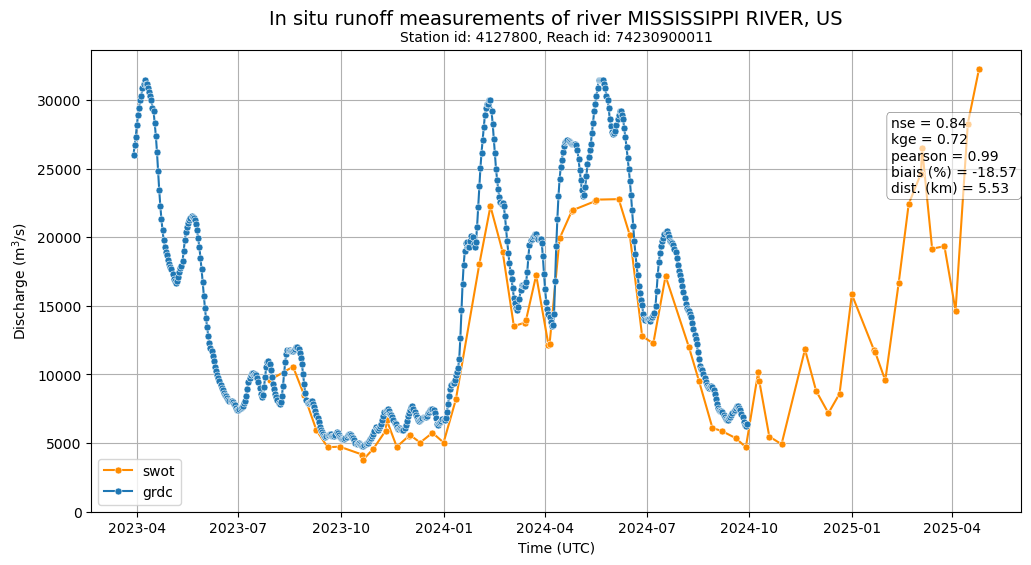

In [61]:
# Make sure the following variables are set correctly before running the code
list_stations_plot = [4127800]
                                # SELECT stations in GRDC database to compare with SWOT data. Enter their stations id in int format.
                                # na
                                # 4127800 : article 3, fig 2a - Mississippi River near Baton Rouge, Louisiana, United States
                                # 4105850 : article 3, fig 2b - Kenai River near Soldotna, Alaska, United States
                                # eu
                                # 6139415 : article 3, fig 2c - Le Drac River near Grenoble, France
                                # sa
                                # 3626000 : amazonie, cours d'eau large de 3 km
                                # 3625000 : amazone
target_date_inf = "2023-07-01" # SELECT a time period for the plots
target_date_sup = "2024-09-21" # SWOT data : 2023-03-29 to 2025-05-02
use_target_date_filter = False # SELECT True if we want to use the above specified target dates, False if the goal is to display the discharge data for all time period available
save = False

# Making the plots          
for station_id in list_stations_plot:
    if station_id in diag_dset['id'].values:
        
        # discharge data
        station_dset = diag_dset.sel(id=station_id)
        reach_id = station_dset['id_s'].values
        if ~np.isnan(reach_id):
            reach_id = reach_id.astype(int) 
            #else: reach_id = "NaN"
        
        # prints
        print(f"Distance between reach and station is {station_dset['distance_d'].item():.2f} km")
        print(f"The closest reach's id: {reach_id}")
        print(f"Station coordinates are ({station_dset['geoy_g'].item()},{station_dset['geox_g'].item()})")
        print(f"Reach coordinates are ({station_dset['geoy_s'].item()},{station_dset['geox_s'].item()})")

        # get river name and country
        river_name = station_dset['river_name_g'].values
        river_country = station_dset['country_g'].values
            
        # plot
        plt.figure(figsize=(12, 6))
        plt.title(f"Station id: {station_id}, Reach id: {reach_id}", fontsize=10) 
        plt.gca().text(0.5, 1.055, f"In situ runoff measurements of river {river_name}, {river_country}", transform=plt.gca().transAxes, ha="center", fontsize=14)
        plt.xlabel('Time (UTC)') 
        plt.ylabel(r'Discharge (m$^3$/s)')
        plt.grid(True)

        # text box with statistics
        distance = station_dset['distance_d'].item()
        biais = station_dset['q_biais_d'].item()
        pearson = station_dset['pearson_corr_d'].item()
        kge = station_dset['kge_d'].item()
        nse = station_dset['nse_d'].item()
        textstr = '\n'.join((
        r'nse = %.2f' % (nse, ),
        r'kge = %.2f' % (kge, ),
        r'pearson = %.2f' % (pearson, ),
        r'biais (%%) = %.2f' % (biais, ),
        r'dist. (km) = %.2f' % (distance, )
        ))
        props = dict(boxstyle='round', facecolor='w', alpha=0.6, lw=0.4) 
        plt.text(0.86, 0.685, textstr, transform=plt.gca().transAxes, fontsize=10, verticalalignment='bottom', bbox=props)

        
        if use_target_date_filter: 
            # slicing data for the right id & time period
            target_datetime_inf = np.datetime64(target_date_inf, 'D')
            target_datetime_sup = np.datetime64(target_date_sup, 'D')
            station_dset = station_dset.sel(time=slice(target_date_inf,target_date_sup)) 
            
            # filtering nans out of the swot data so that each dot in the graph is connected to another (the "orange problem")
            dschg_swt = station_dset['dschg_s']
            or_mask = ~np.isnan(dschg_swt.values)

            plt.plot(dschg_swt.time.values[or_mask],dschg_swt.values[or_mask], marker='o', markersize=5, label='swot', color='darkorange', markeredgecolor='white', markeredgewidth=0.4, linestyle='-')
            plt.plot(station_dset['dschg_g'].time.values, station_dset['dschg_g'].values, marker='o', markersize=5, label='grdc', color='tab:blue', alpha=1, markeredgecolor='white', markeredgewidth=0.4)
            plt.legend()
            fig_name = f'discharge_s{station_id}_r{reach_id}_{target_date_inf}_{target_date_sup}.png'
        else:
            # filtering nans out of the swot data so that each dot in the graph is connected to another (the "orange problem")
            dschg_swt = station_dset['dschg_s']
            or_mask = ~np.isnan(dschg_swt.values)

            plt.plot(dschg_swt.time.values[or_mask],dschg_swt.values[or_mask], marker='o', markersize=5, label='swot', color='darkorange', markeredgecolor='white', markeredgewidth=0.4, linestyle='-')
            plt.plot(station_dset['dschg_g'].time.values, station_dset['dschg_g'].values, marker='o', markersize=5, label='grdc', color='tab:blue', alpha=1, markeredgecolor='white', markeredgewidth=0.4)
            plt.legend()
            fig_name = f'discharge_s{station_id}_r{reach_id}.png' #f'discharge_comparison_station{station_id}_r{reach_id}.png'
        
        if save:
            plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
            print(f"Figure saved") # *** currently no error message if one of the station required to be plotted isn't in the GRDC data -> print(f"There is no correspondence in the GRDC in situ files for station id {station_id}")
        
        plt.ylim(0,None)
        plt.show()  
    else:
        print(f'Error: the station {station_id} is not in the list of station ids from the GRDC data')


#### Better station time series

Distance between reach and station is 5.53 km
The closest reach's id: 74230900011
Station coordinates are (32.3146,-90.9062)
Reach coordinates are (32.3447032532689,-90.9529691465538)


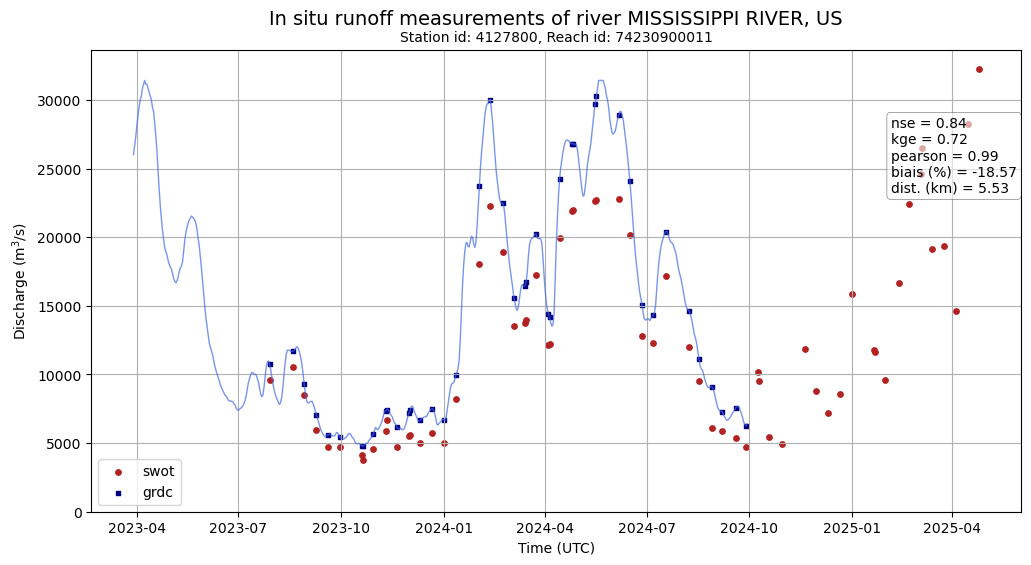

In [38]:
# Make sure the following variables are set correctly before running the code
list_stations_plot = [4127800]
target_date_inf = "2023-07-01" # SELECT a time period for the plots
target_date_sup = "2024-09-21" # SWOT data : 2023-03-29 to 2025-05-02
use_target_date_filter = False # SELECT True if we want to use the above specified target dates, False if the goal is to display the discharge data for all time period available
save = False

# Making the plots          
for station_id in list_stations_plot:
    if station_id in diag_dset['id'].values:
        
        # discharge data
        station_dset = diag_dset.sel(id=station_id)
        reach_id = station_dset['id_s'].values
        if ~np.isnan(reach_id):
            reach_id = reach_id.astype(int) 
            #else: reach_id = "NaN"
        
        # prints
        print(f"Distance between reach and station is {station_dset['distance_d'].item():.2f} km")
        print(f"The closest reach's id: {reach_id}")
        print(f"Station coordinates are ({station_dset['geoy_g'].item()},{station_dset['geox_g'].item()})")
        print(f"Reach coordinates are ({station_dset['geoy_s'].item()},{station_dset['geox_s'].item()})")

        # get river name and country
        river_name = station_dset['river_name_g'].values
        river_country = station_dset['country_g'].values
            
        # plot
        plt.figure(figsize=(12, 6))
        plt.title(f"Station id: {station_id}, Reach id: {reach_id}", fontsize=10) 
        plt.gca().text(0.5, 1.055, f"In situ runoff measurements of river {river_name}, {river_country}", transform=plt.gca().transAxes, ha="center", fontsize=14)
        plt.xlabel('Time (UTC)') 
        plt.ylabel(r'Discharge (m$^3$/s)')
        plt.grid(True)

        # text box with statistics
        distance = station_dset['distance_d'].item()
        biais = station_dset['q_biais_d'].item()
        pearson = station_dset['pearson_corr_d'].item()
        kge = station_dset['kge_d'].item()
        nse = station_dset['nse_d'].item()
        textstr = '\n'.join((
        r'nse = %.2f' % (nse, ),
        r'kge = %.2f' % (kge, ),
        r'pearson = %.2f' % (pearson, ),
        r'biais (%%) = %.2f' % (biais, ),
        r'dist. (km) = %.2f' % (distance, )
        ))
        props = dict(boxstyle='round', facecolor='w', alpha=0.6, lw=0.4) 
        plt.text(0.86, 0.685, textstr, transform=plt.gca().transAxes, fontsize=10, verticalalignment='bottom', bbox=props)

        # plot swot
        plt.scatter(station_dset['dschg_s'].time.values, station_dset['dschg_s'].values, label='swot', marker='o', s=15, color='firebrick')

        # plot grdc
        q_g = station_dset['dschg_g']
        q_s = station_dset['dschg_s']
        mask_coincide = (q_g.notnull() & q_s.notnull())
        plt.plot(q_g.time.values, q_g.values, color='royalblue', alpha=0.7, markeredgecolor='white', markeredgewidth=0.4, linewidth=1)
        plt.scatter(q_g.time.values[mask_coincide],q_g.values[mask_coincide], marker='s', s=6, label='grdc', color='navy')

        plt.legend()
        fig_name = f'discharge_s{station_id}_r{reach_id}.png' #f'discharge_comparison_station{station_id}_r{reach_id}.png'
        
        if save:
            plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
            print(f"Figure saved") # *** currently no error message if one of the station required to be plotted isn't in the GRDC data -> print(f"There is no correspondence in the GRDC in situ files for station id {station_id}")
        
        plt.ylim(0,None)
        plt.show()  
    else:
        print(f'Error: the station {station_id} is not in the list of station ids from the GRDC data')


#### Multiplot of random time series

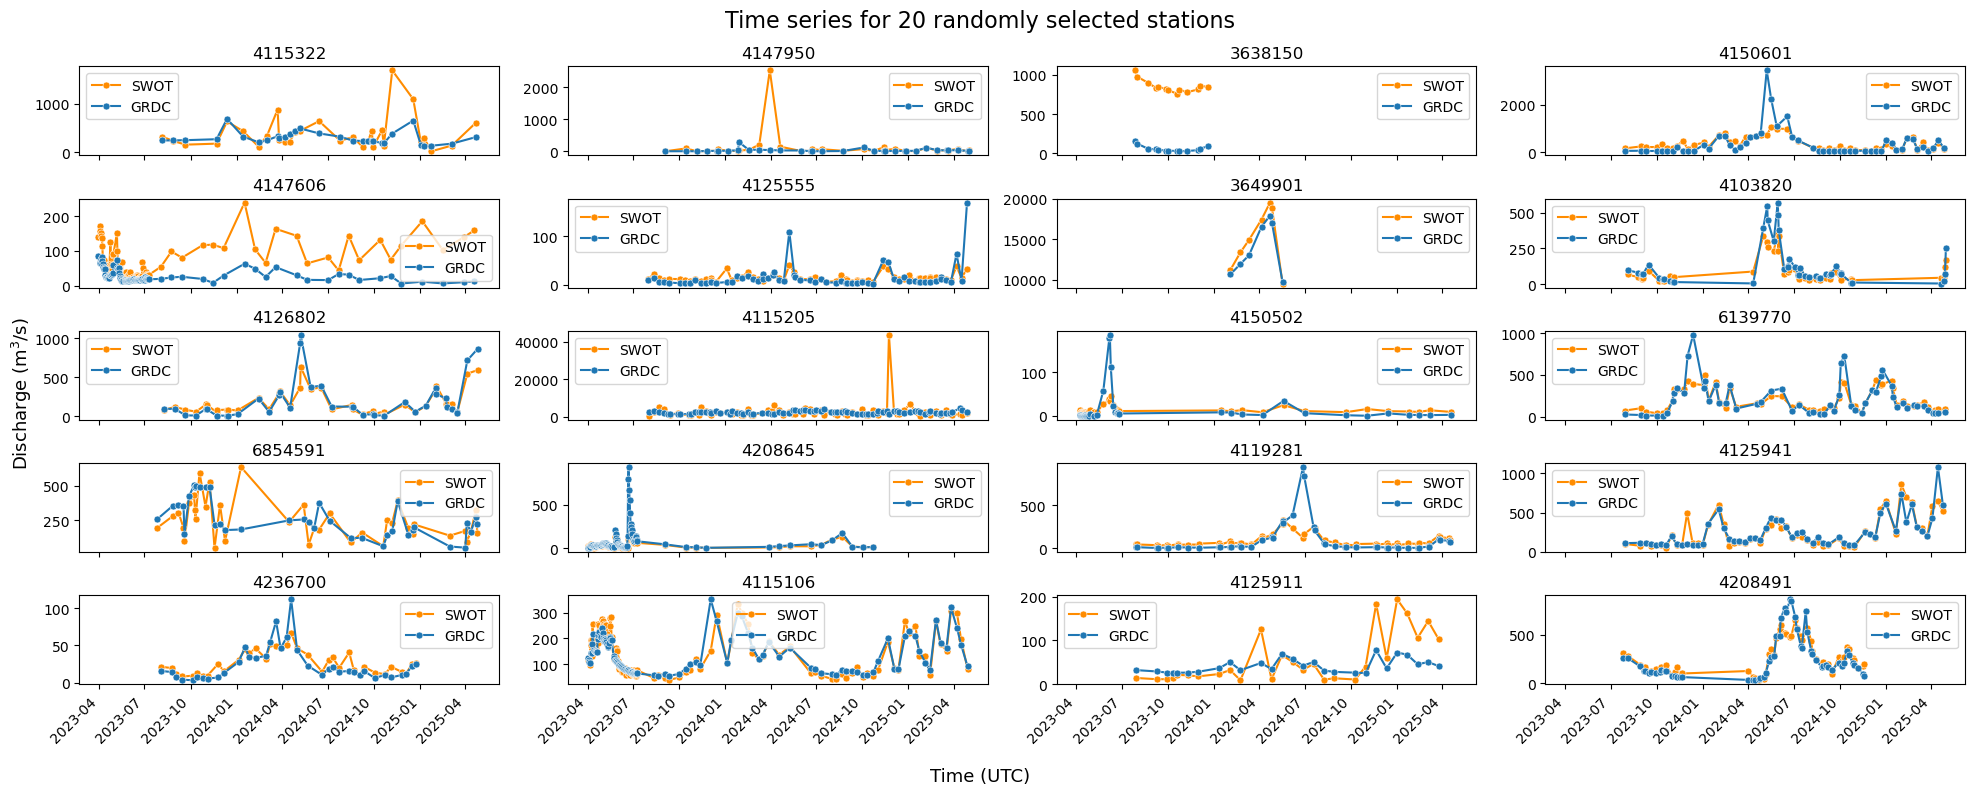

Saved.


<Figure size 640x480 with 0 Axes>

In [ ]:
# Select n random ids
length = 5
width = 4
n_random = length*width
overlap_mask = diag_dset['match'].values
overlap_ids = diag_dset['id'].values[overlap_mask]
ids_random = random.sample(list(overlap_ids), k=n_random)

# Plot
fig, ax = plt.subplots(5,4,sharex=True, sharey=False, figsize=(20, 8))
fig.suptitle(f"Time series for {n_random} randomly selected stations", fontsize=16)
fig.supxlabel('Time (UTC)', fontsize=13)
fig.supylabel(r'Discharge (m$^3$/s)', fontsize=13, x=0.015)

i_id = 0
for l in range(length):
    for w in range(width):
        # select data
        station_id = ids_random[i_id].astype(int) 
        station_dset = diag_dset.sel(id=station_id)
        q_g = station_dset['dschg_g']
        q_s = station_dset['dschg_s']
        r_id = station_dset['id_s'].astype(int)

        # filtering nans out of the swot data + keeping only days when swot has data
        mask_coincide = (q_g.notnull() & q_s.notnull())

        # plot
        ax[l,w].set_title(f"{station_id}")
        ax[l,w].plot(q_s.time.values[mask_coincide],q_s.values[mask_coincide], marker='o', markersize=5, label='SWOT', color='darkorange', markeredgecolor='white', markeredgewidth=0.4, linestyle='-')
        ax[l,w].plot(q_g.time.values[mask_coincide], q_g.values[mask_coincide], marker='o', markersize=5, label='GRDC', color='tab:blue', alpha=1, markeredgecolor='white', markeredgewidth=0.4)
        ax[l,w].legend()

        # increment
        i_id += 1

# Skewed date labels 
for ax_row in ax:
    for ax_col in ax_row:
        plt.setp(ax_col.get_xticklabels(), rotation=45, ha='right')

# Save    
plt.tight_layout()
plt.show()  
fig_name = f'random_time_series.png' #f'discharge_comparison_station{station_id}_r{closest_reach_id}.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Saved.") # *** currently no error message if one of the station required to be plotted isn't in the GRDC data -> print(f"There is no correspondence in the GRDC in situ files for station id {station_id}")


### **Map of the SWORD reaches**

Figure saved.


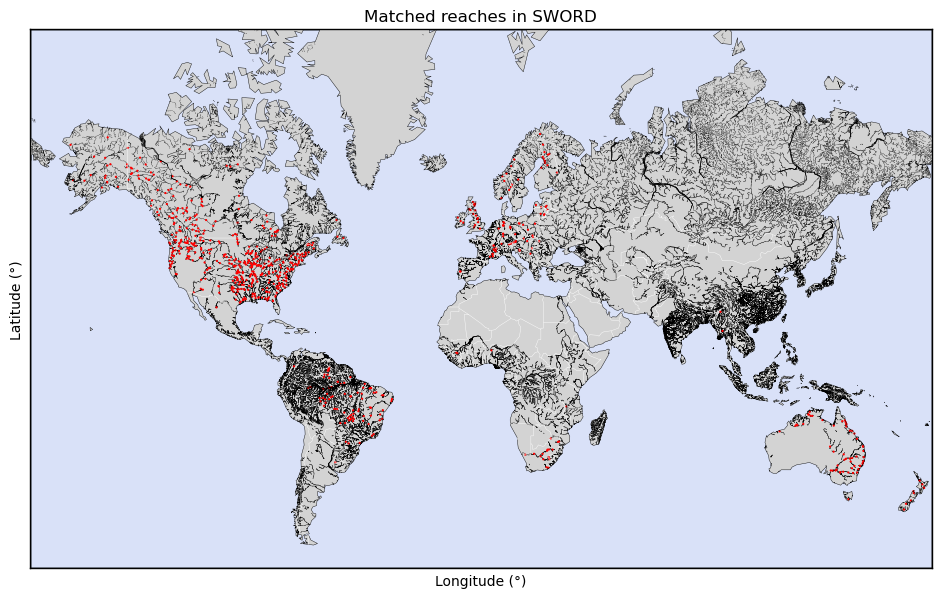

In [66]:
# Coordinates of matched reaches
overlap_mask = diag_dset['match'].values
x_s = diag_dset['geox_s'].values[overlap_mask]
y_s = diag_dset['geoy_s'].values[overlap_mask]

# Coordinates of all sword reaches
x_swr = dset_sword['x_swr'].values
y_swr = dset_sword['y_swr'].values

# Make sure coordinates of matched reaches are in sword
"""print(len(y_ol_s))
print(len(y_swr))
print(len(set(y_ol_s) & set(y_swr)))"""
#assert len(x_ol_s) == len(set(x_ol_s) & set(x_swr)) # *** don't know why but out of the 729 matches, 717 coordinates were found in sword. don't know why the other 12 don't match

# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.3)
map.drawcountries(color='w',linewidth=0.3)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='lightgray', lake_color='lightgray')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot black dots - sword
x, y = map(x_swr, y_swr)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, marker=".", s=0.5, c = 'k', edgecolor='none') # s is markersize, [vmin=0,vmax=5000]

# Plot red dots - match
x, y = map(x_s, y_s)  
mymap = map.scatter(x, y, marker=".", s=10, c = 'r', edgecolor='none') # s is markersize, [vmin=0,vmax=5000]

plt.title("Matched reaches in SWORD") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'sword_global_map.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=800, bbox_inches='tight')
print(f"Figure saved.") 
plt.show()


## **Multiple diagnostics**

#### Width

/tmp/ipykernel_33275/2154064074.py:16: RuntimeWarning: invalid value encountered in log
  ax[3].scatter(np.log(diag_dset['width_s']), np.log(diag_dset['q_biais_d'].values), c='seagreen', alpha=0.5, edgecolors='none')


Figure saved


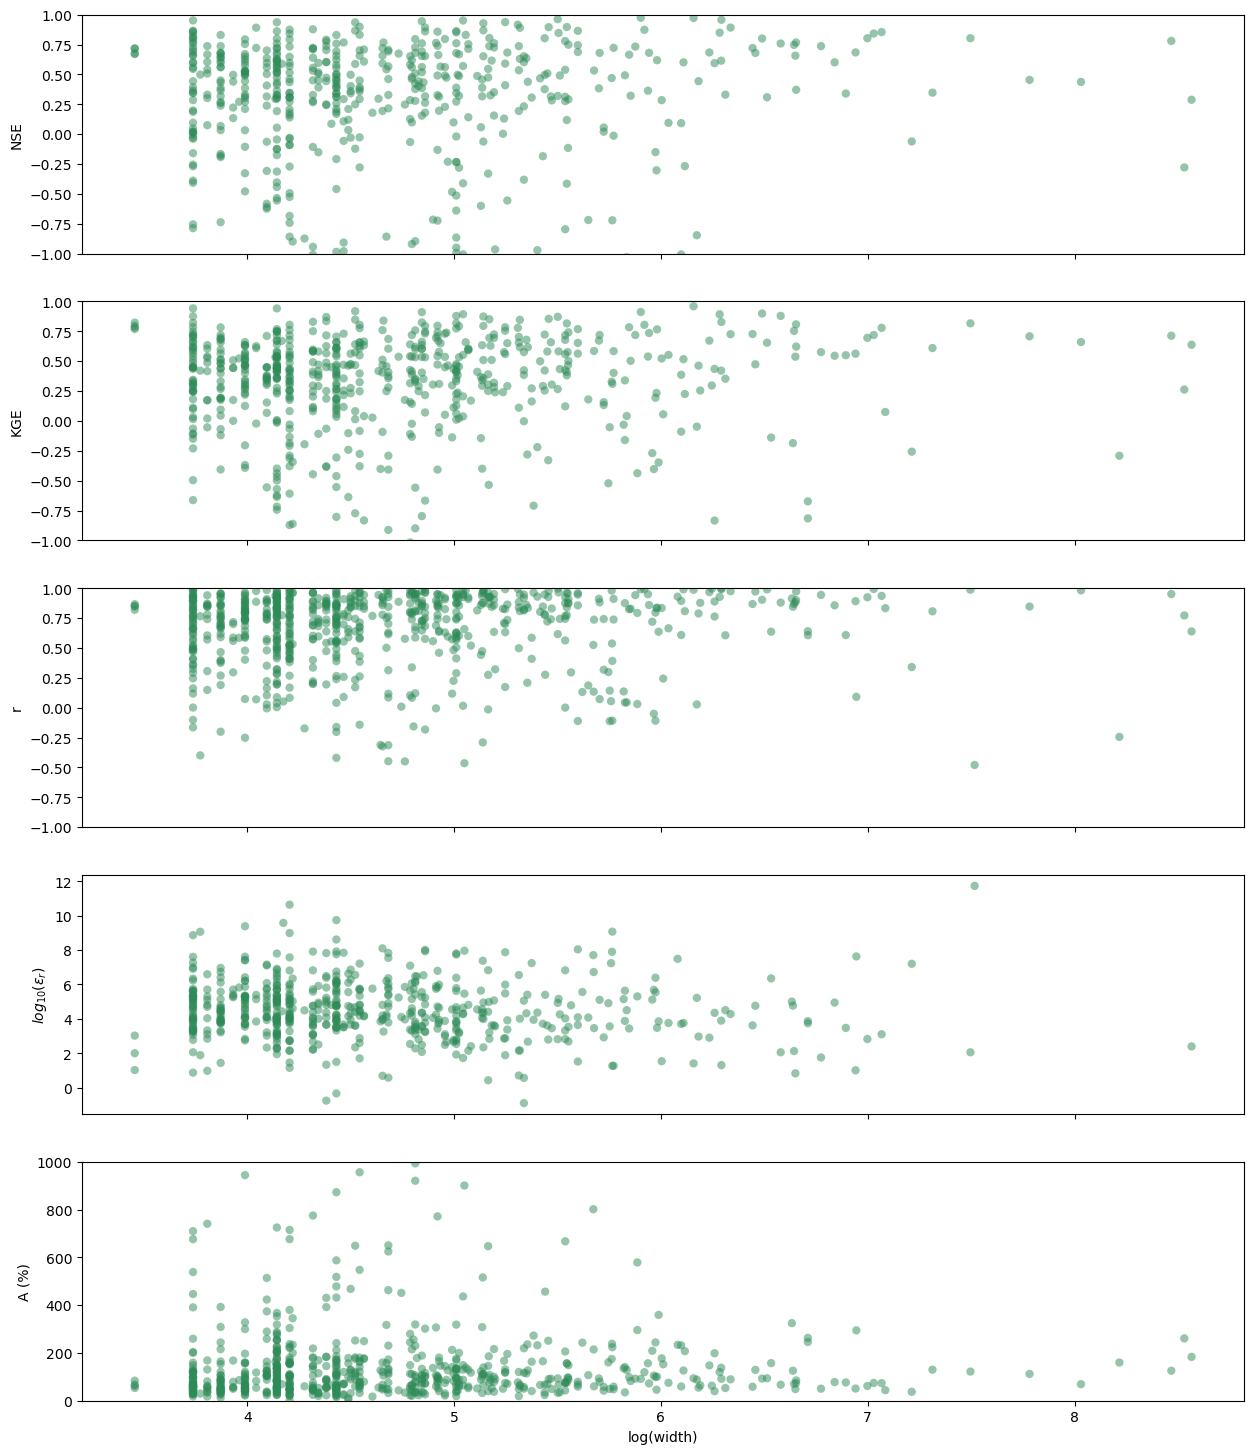

In [16]:
fig, ax = plt.subplots(5,1,sharex=True, sharey=False, figsize=(15, 18))

# Plot
ax[0].scatter(np.log(diag_dset['width_s']), diag_dset['nse_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
ax[0].set_ylim((-1,1))
ax[0].set_ylabel(r'NSE')

ax[1].scatter(np.log(diag_dset['width_s']), diag_dset['kge_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
ax[1].set_ylim((-1,1))
ax[1].set_ylabel(r'KGE')

ax[2].scatter(np.log(diag_dset['width_s']), diag_dset['pearson_corr_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
ax[2].set_ylim((-1,1))
ax[2].set_ylabel(r'r')

ax[3].scatter(np.log(diag_dset['width_s']), np.log(diag_dset['q_biais_d'].values), c='seagreen', alpha=0.5, edgecolors='none')
ax[3].set_ylabel(r'$log_{10}(\varepsilon_r)$')

ax[4].scatter(np.log(diag_dset['width_s']), diag_dset['ampli_percentage_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
ax[4].set_ylim((0,1000))
ax[4].set_ylabel(r'A (%)')
ax[4].set_xlabel(r'log(width)')

# Save
fig_name = f'subplots_width.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()


#### Distance

/tmp/ipykernel_33275/1944123392.py:25: RuntimeWarning: invalid value encountered in log
  ax[3].scatter(diag_dset['distance_d'], np.log(diag_dset['q_bias_d'].values), c='seagreen', alpha=0.5, edgecolors='none',s=n_co*.5)


Figure saved


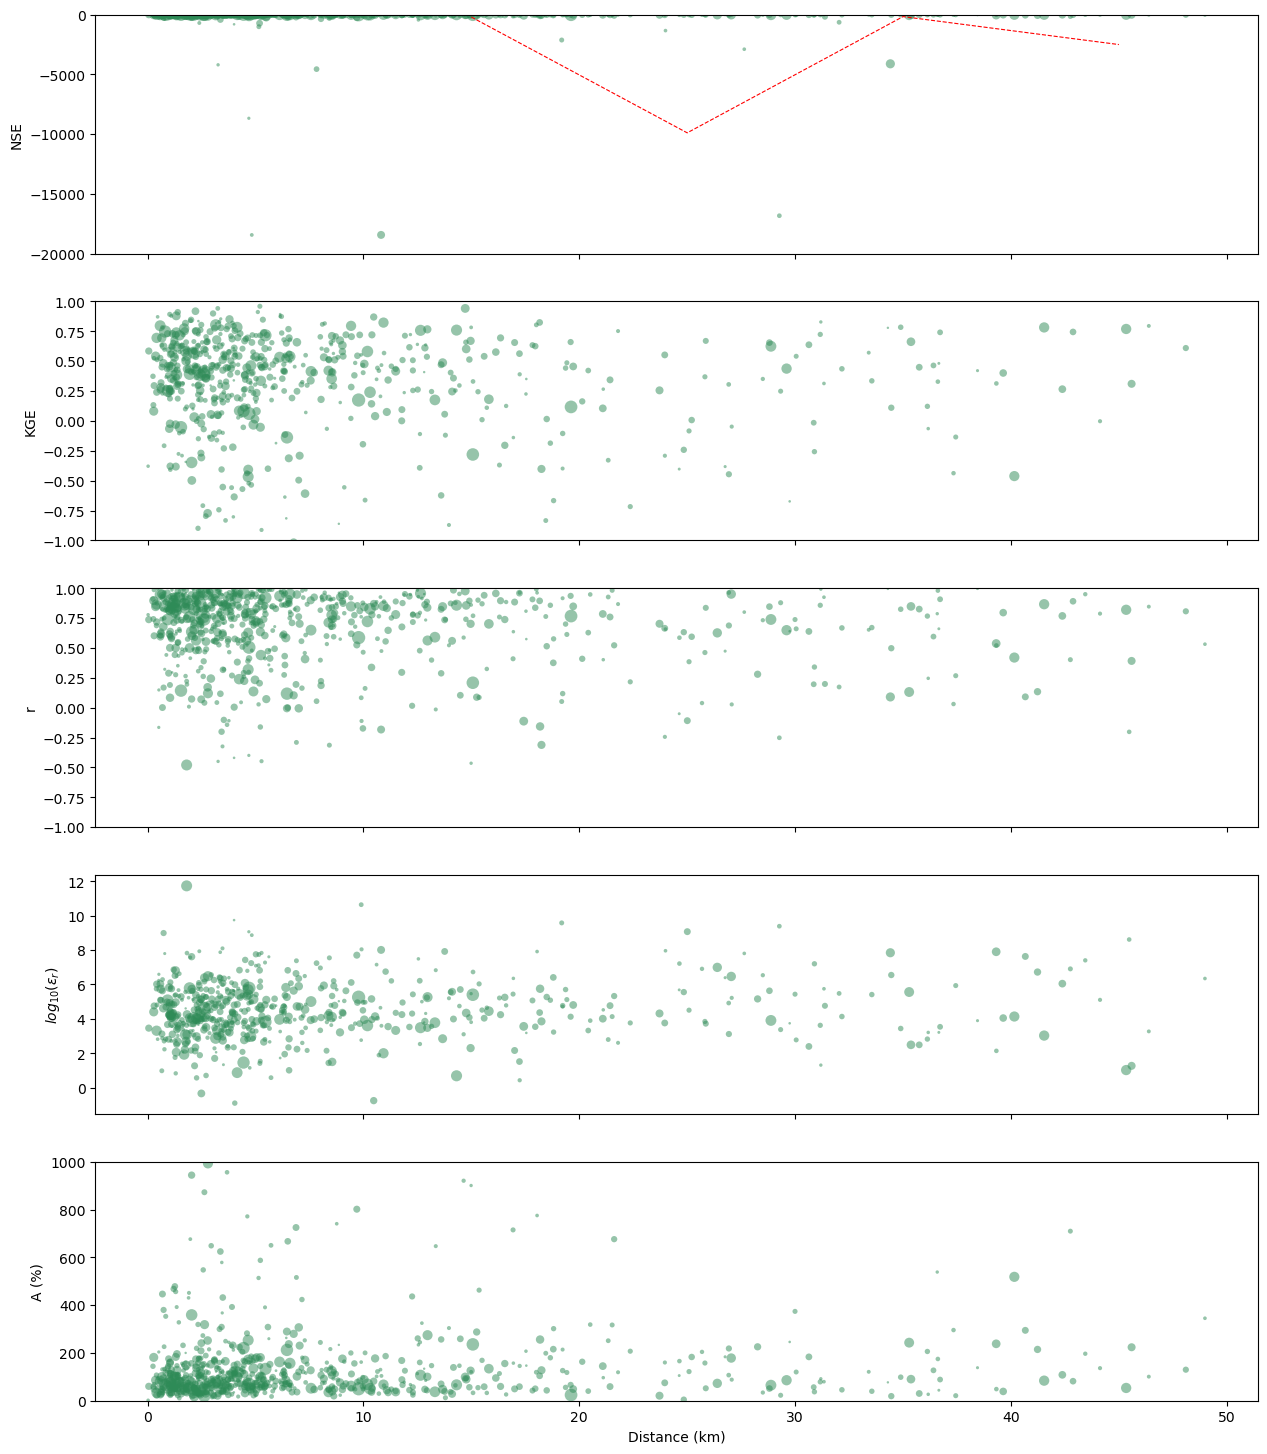

In [111]:
fig, ax = plt.subplots(5,1,sharex=True, sharey=False, figsize=(15, 18))

# Size of dots
n_co = diag_dset['n_coincide'].values

# Tendency line (group by bins, compute mean)
bins = np.array([0,10,20,30,40,50])
xticks = np.array([5,15,25,35,45])

# Plot
ax[0].scatter(diag_dset['distance_d'], diag_dset['nse_d'].values, c='seagreen', alpha=0.5, edgecolors='none',s=n_co*.5)
ax[0].set_ylim((-20000,1))
ax[0].set_ylabel(r'NSE')
mean_nse_per_bin = diag_dset['nse_d'].groupby_bins(diag_dset['distance_d'], bins=bins).mean()
ax[0].plot(xticks, mean_nse_per_bin.values, c='r', linestyle='--', linewidth = 0.8)

ax[1].scatter(diag_dset['distance_d'], diag_dset['kge_d'].values, c='seagreen', alpha=0.5, edgecolors='none',s=n_co*.5)
ax[1].set_ylim((-1,1))
ax[1].set_ylabel(r'KGE')

ax[2].scatter(diag_dset['distance_d'], diag_dset['pearson_corr_d'].values, c='seagreen', alpha=0.5, edgecolors='none',s=n_co*.5)
ax[2].set_ylim((-1,1))
ax[2].set_ylabel(r'r')

ax[3].scatter(diag_dset['distance_d'], np.log(diag_dset['q_bias_d'].values), c='seagreen', alpha=0.5, edgecolors='none',s=n_co*.5)
ax[3].set_ylabel(r'$log_{10}(\varepsilon_r)$')

ax[4].scatter(diag_dset['distance_d'], diag_dset['ampli_pct_d'].values, c='seagreen', alpha=0.5, edgecolors='none',s=n_co*.5)
ax[4].set_ylim((0,1000))
ax[4].set_ylabel(r'A (%)')

ax[4].set_xlabel(r'Distance (km)')

# Save
fig_name = f'subplots_distance.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()


#### Mean discharge

/tmp/ipykernel_33275/383503032.py:19: RuntimeWarning: invalid value encountered in log
  ax[3].scatter(np.log(diag_dset['dschg_s'].mean(dim='time', skipna=True)), np.log(diag_dset['q_bias_d'].values), c='seagreen', alpha=0.5, edgecolors='none', s=n_co*.5)


Figure saved


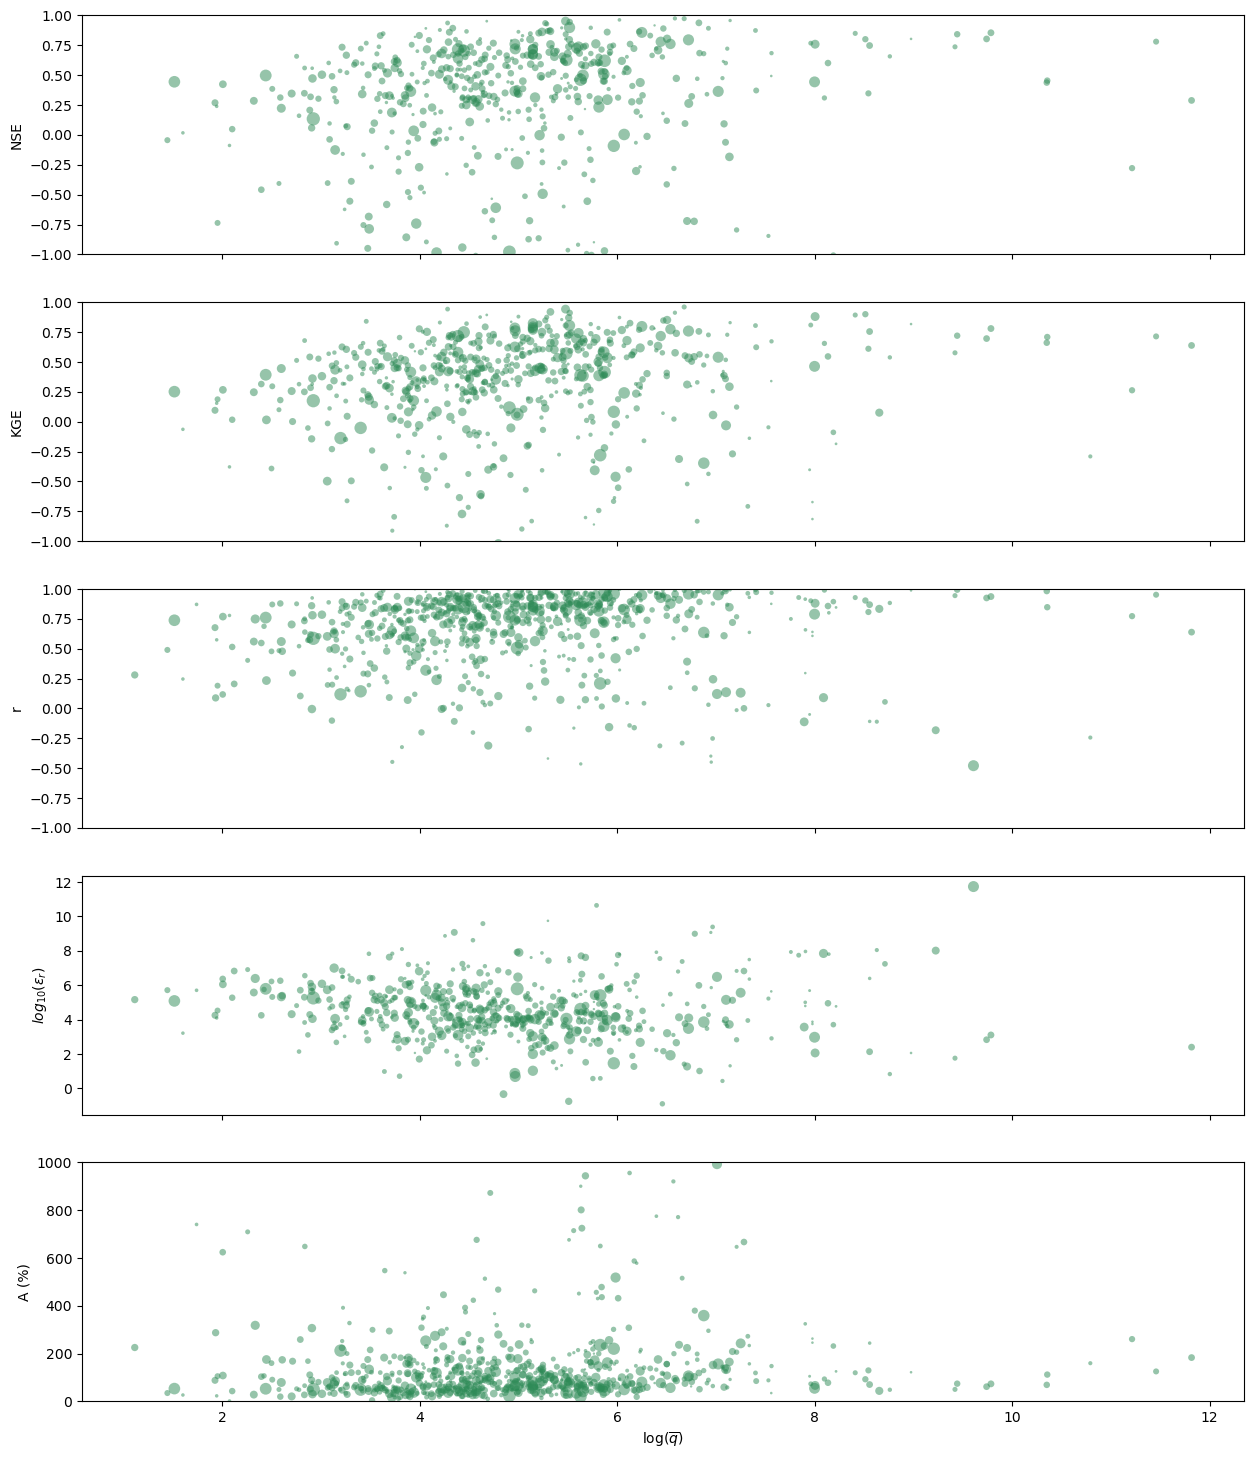

In [88]:
fig, ax = plt.subplots(5,1,sharex=True, sharey=False, figsize=(15, 18))

# Size of dots
n_co = diag_dset['n_coincide'].values

# Plot
ax[0].scatter(np.log(diag_dset['dschg_s'].mean(dim='time', skipna=True)), diag_dset['nse_d'].values, c='seagreen', alpha=0.5, edgecolors='none', s=n_co*.5)
ax[0].set_ylim((-1,1))
ax[0].set_ylabel(r'NSE')

ax[1].scatter(np.log(diag_dset['dschg_s'].mean(dim='time', skipna=True)), diag_dset['kge_d'].values, c='seagreen', alpha=0.5, edgecolors='none', s=n_co*.5)
ax[1].set_ylim((-1,1))
ax[1].set_ylabel(r'KGE')

ax[2].scatter(np.log(diag_dset['dschg_s'].mean(dim='time', skipna=True)), diag_dset['pearson_corr_d'].values, c='seagreen', alpha=0.5, edgecolors='none', s=n_co*.5)
ax[2].set_ylim((-1,1))
ax[2].set_ylabel(r'r')

ax[3].scatter(np.log(diag_dset['dschg_s'].mean(dim='time', skipna=True)), np.log(diag_dset['q_bias_d'].values), c='seagreen', alpha=0.5, edgecolors='none', s=n_co*.5)
ax[3].set_ylabel(r'$log_{10}(\varepsilon_r)$')

ax[4].scatter(np.log(diag_dset['dschg_s'].mean(dim='time', skipna=True)), diag_dset['ampli_pct_d'].values, c='seagreen', alpha=0.5, edgecolors='none', s=n_co*.5)
ax[4].set_ylim((0,1000))
ax[4].set_ylabel(r'A (%)')

ax[4].set_xlabel(r'log($\overline{q}$)')

# Save
fig_name = f'subplots_mean_q.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()


## **Diagnostic : NSE**

#### Width

Figure saved


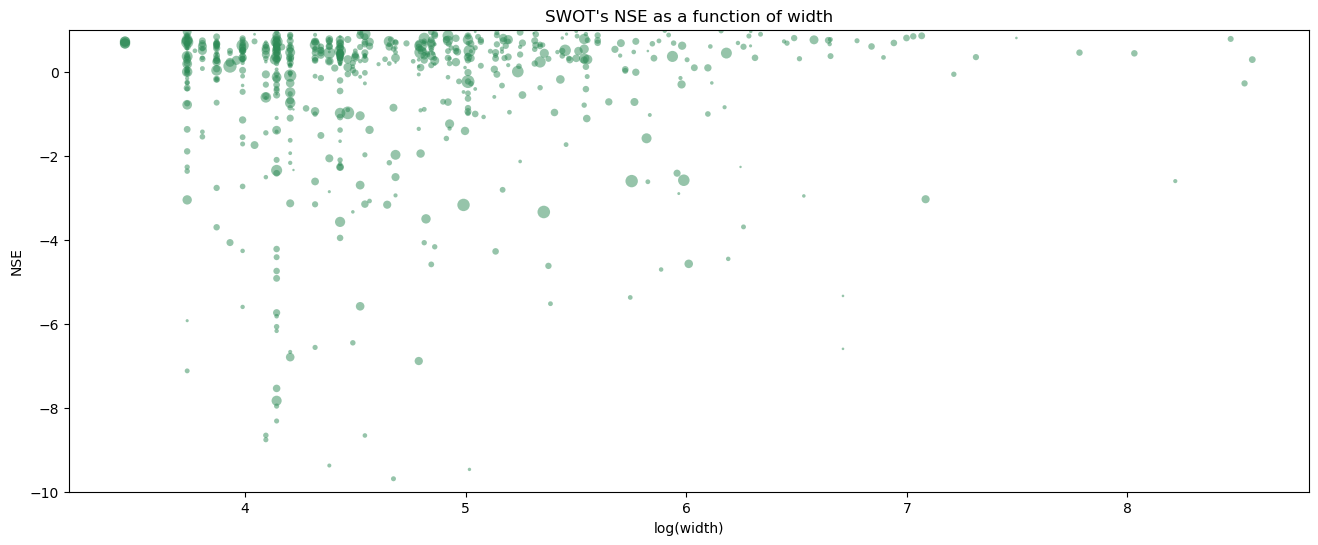

In [92]:
# Size of dots
n_co = diag_dset['n_coincide'].values

# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(np.log(diag_dset['width_s']), diag_dset['nse_d'].values, c='seagreen', alpha=0.5, edgecolors='none', s=n_co*.5)
plt.ylim((-10,1))
#plt.xlim((0,1000))
plt.title("SWOT's NSE as a function of width") 
plt.xlabel(r'log(width)')
plt.ylabel(r'NSE')

# Save
fig_name = f'nse_width.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

Figure saved


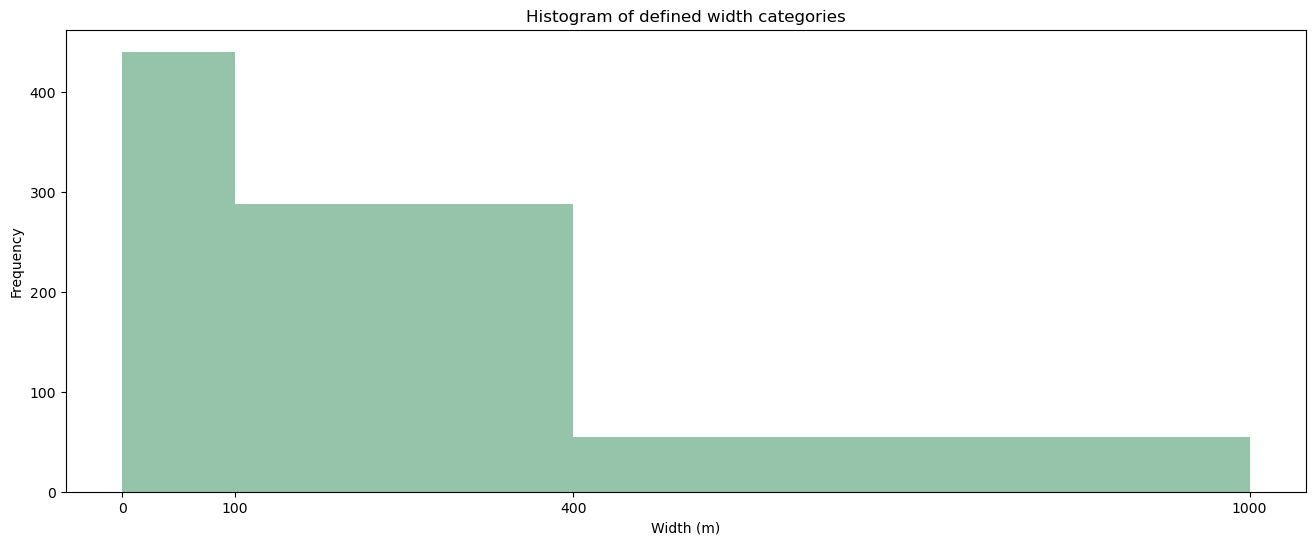

In [12]:
# Width
width = diag_dset['width_s'].values
nse = diag_dset['nse_d'].values

# Clipping the very high values (including infinites) to a defined maximum
min = 0
max = 1000
clip = np.clip(width,min,max)
my_bins = [0,100,400,1000]

# Plot
plt.figure(figsize=(16, 6))
plt.hist(clip, bins=my_bins, color = 'seagreen', alpha=0.5)
plt.title(f"Histogram of defined width categories") 
#plt.ylim((0,1750))
plt.xticks(my_bins)
plt.xlabel('Width (m)') 
plt.ylabel('Frequency')

# Save
fig_name = f'width_hist.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved")
plt.show()


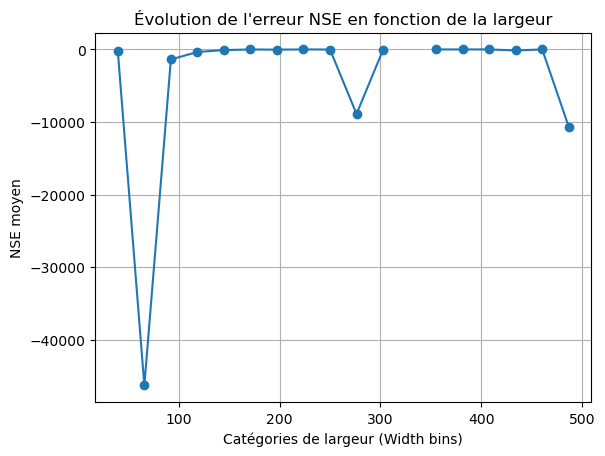

In [18]:
# Statistics
width = diag_dset['width_s']
nse = diag_dset['nse_d']

# Bins
min = 0
max = 500 # m
bins = np.linspace(min, max, num=20)
clip = np.clip(width,min,max)

# Groupby
mean_nse_per_bin = nse.groupby_bins(clip, bins=bins).mean()

# Plot
mean_nse_per_bin.plot(marker='o', linestyle='-')
plt.xlabel("Catégories de largeur (Width bins)")
plt.ylabel("NSE moyen")
#plt.ylim((-1,1))
plt.title("Évolution de l'erreur NSE en fonction de la largeur")
plt.grid(True)
plt.show()

#### Distance

Figure saved


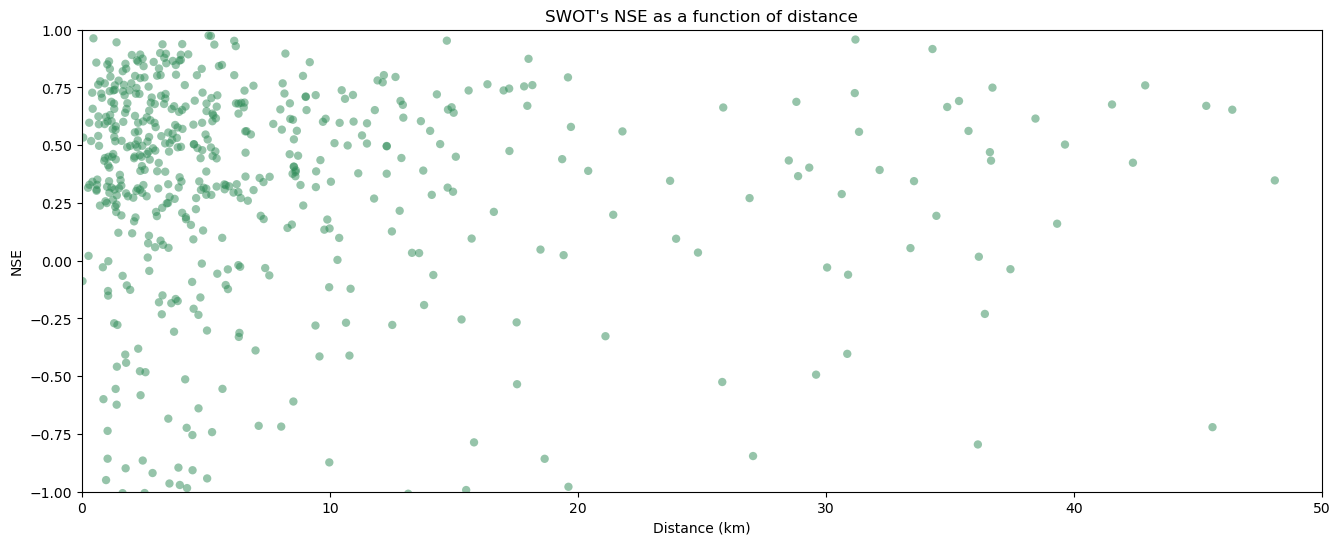

CONDITION: nse<=2000 -> [4125802 4152202 4152450 4204010 4213031 1159305 1196405 6139290 6233223
 6574350 6604220 3650924 3650925 3652220 5204251 5204252]


In [ ]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(diag_dset['distance_d'], diag_dset['nse_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((-1,1))
plt.xlim((0,50))
plt.title("SWOT's NSE as a function of distance") 
plt.xlabel(r'Distance (km)')
plt.ylabel(r'NSE')

# Save
fig_name = f'nse_distance.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

# Select points
## nse<-2000
condition = (
    (diag_dset['nse_d'] <= -2000)
)
stations_ids_list = diag_dset.id[condition].values
print("CONDITION: nse<=-2000 ->",stations_ids_list)

#### Mean swot discharge

Figure saved


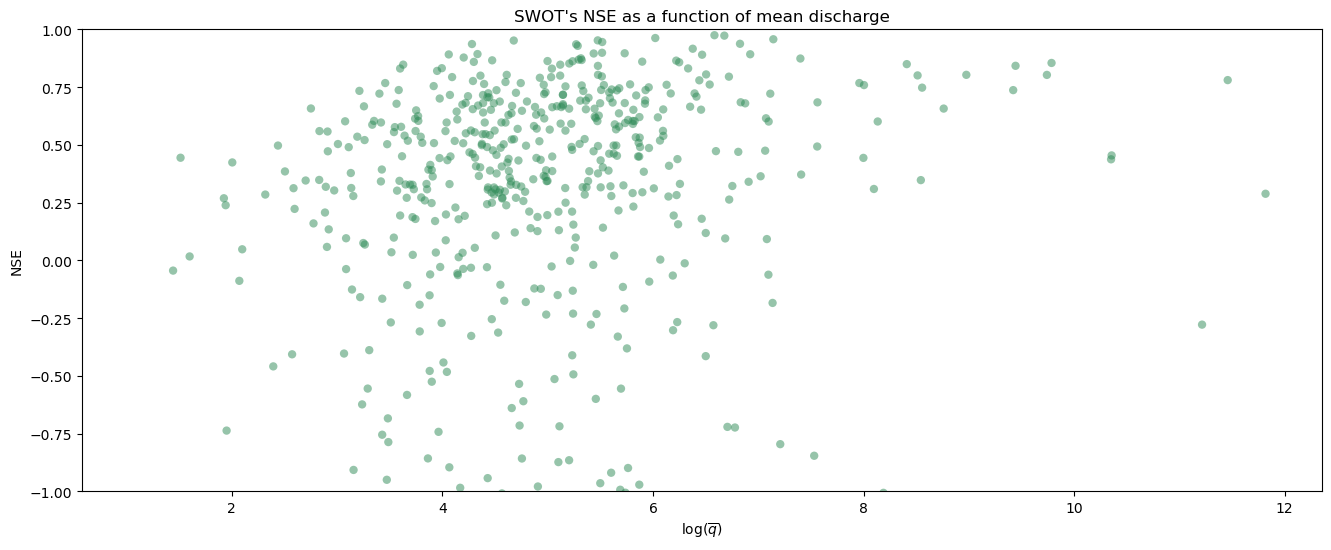

In [6]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(np.log(diag_dset['dschg_s'].mean(dim='time', skipna=True)), diag_dset['nse_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((-1,1))
#plt.xlim((0,5000))
plt.title("SWOT's NSE as a function of mean discharge") 
plt.xlabel(r'log($\overline{q}$)')
plt.ylabel(r'NSE')

# Save
fig_name = f'nse_mean_q_s.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Global map

Figure saved in /obs/ecastonguay/scripts/figures


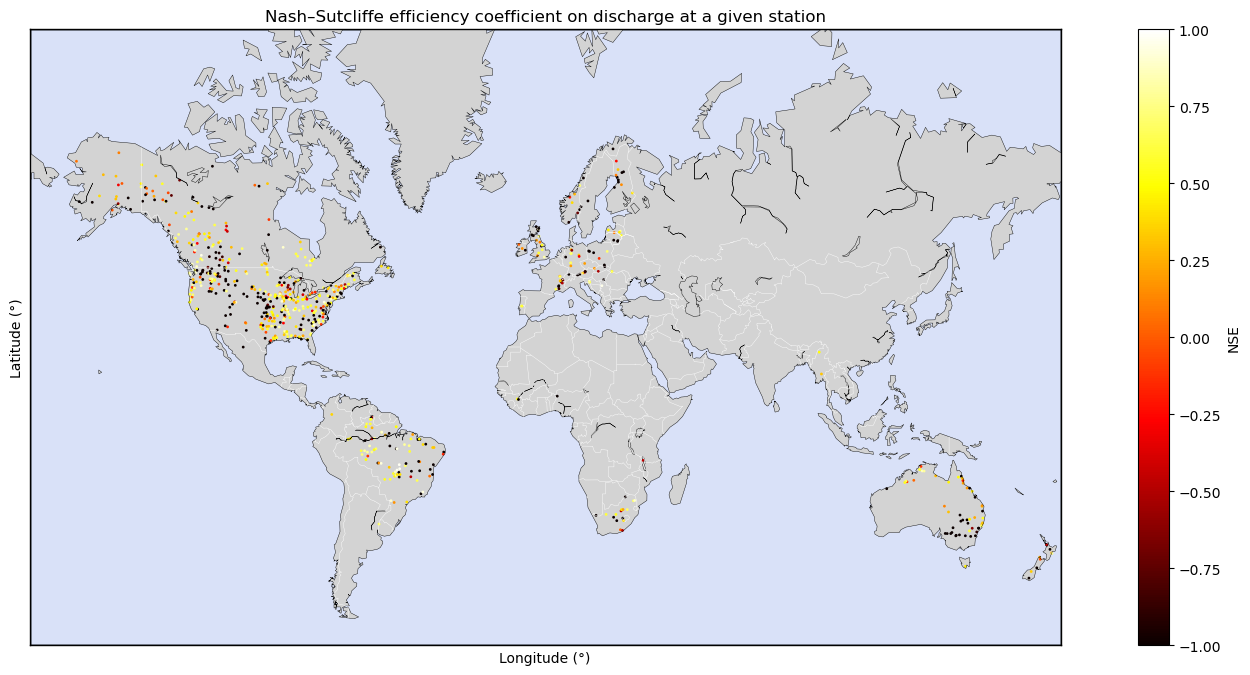

In [8]:
# Determine the 'view' of the world map
plt.figure(figsize=(20, 8))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.3)
map.drawcountries(color='w',linewidth=0.3)
map.drawmapboundary(fill_color=ocean_color) # ocean color
map.fillcontinents(color='lightgray', lake_color='lightgray')
#map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(diag_dset['geox_s'].values, diag_dset['geoy_s'].values)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=diag_dset['nse_d'].values, cmap='hot', marker='o', alpha=1, s=1, vmin=-1,vmax=1) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label='NSE')
plt.title("Nash–Sutcliffe efficiency coefficient on discharge at a given station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'nse_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

## **Diagnostic : KGE**

#### Width

Figure saved


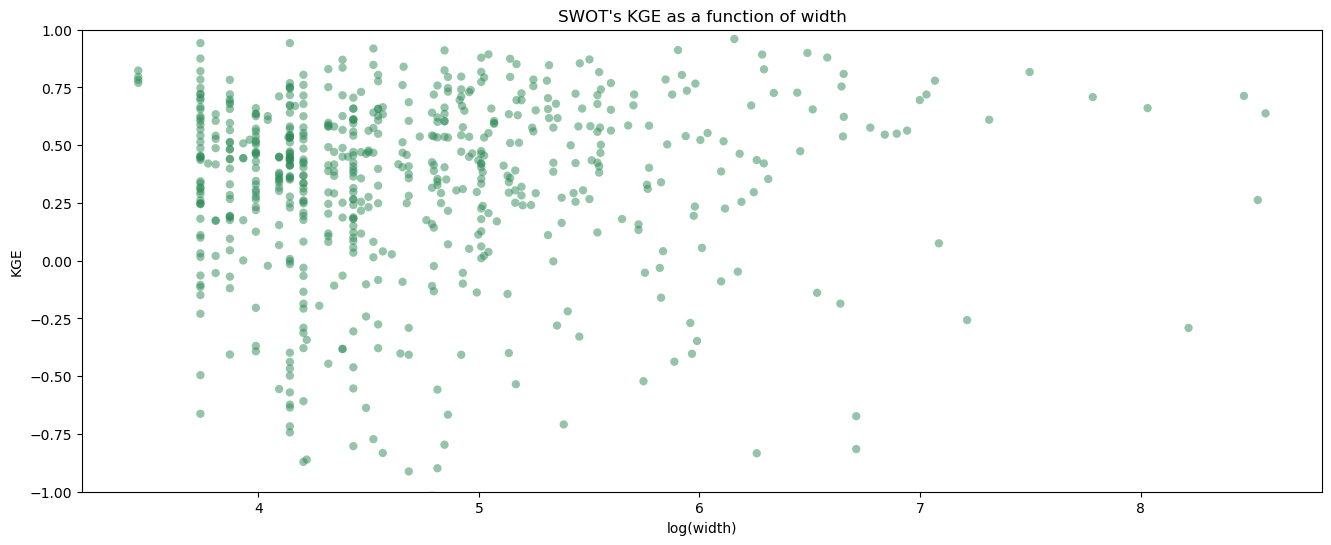

In [25]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(np.log(diag_dset['width_s']), diag_dset['kge_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((-1,1))
#plt.xlim((0,1000))
plt.title("SWOT's KGE as a function of width") 
plt.xlabel(r'log(width)')
plt.ylabel(r'KGE')

# Save
fig_name = f'kge_width.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Area bias

Figure saved


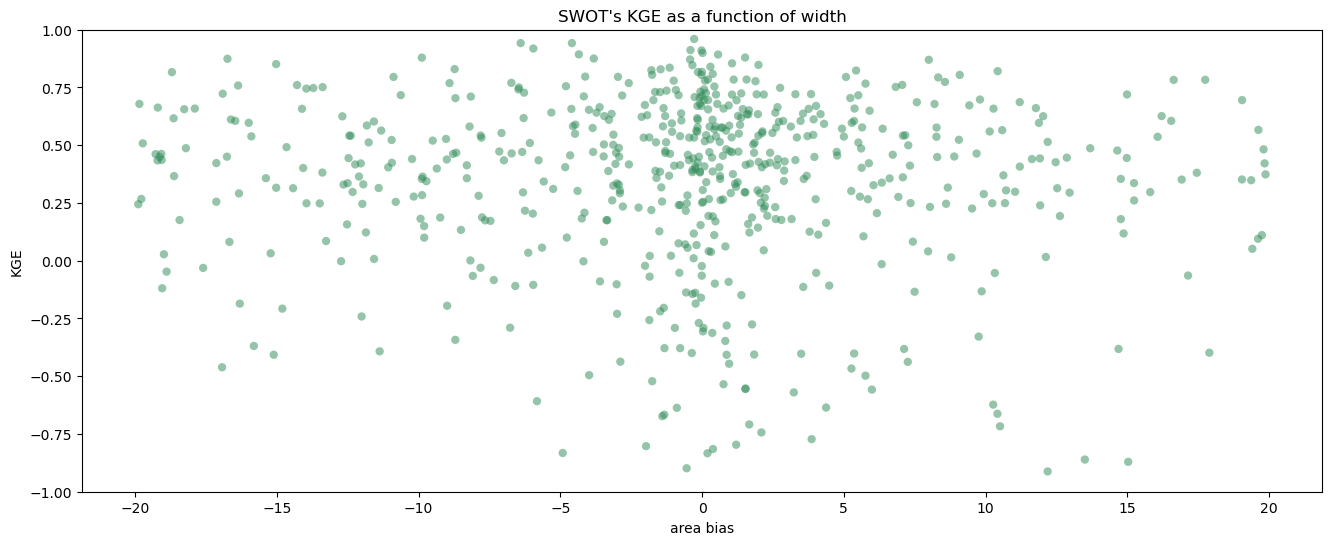

CONDITION: kge<0, bias+-5% -> [4105710 4105720 4115203 4115204 4115260 4115322 4115348 4115403 4115700
 4116183 4116186 4116187 4116190 4119447 4119650 4120120 4120330 4120953
 4121146 4121400 4122153 4122201 4122222 4122240 4122350 4122602 4122603
 4122637 4122638 4122650 4122701 4123380 4125062 4125063 4125802 4125804
 4125911 4126851 4132200 4136400 4147320 4147380 4147460 4147606 4147651
 4147950 4148325 4148410 4148550 4149441 4149690 4149781 4150450 4150451
 4150500 4150501 4152202 4152400 4152550 4152553 4152580 4152590 4152701
 4204010 4207180 4208335 4208386 4208440 4213033 4244301 4351025 1159100
 1159302 1196405 1634500 1834010 6139290 6139345 6139350 6243030 6243050
 6335030 6444110 6457800 6457810 6457820 6458406 6574350 6604220 6605695
 6605780 6605800 6731910 6854500 6854600 6854701 6854703 6854800 6935305
 3618711 3625000 3637380 3638051 3638150 3649160 3649251 3649421 3650359
 3650380 3650471 3652068 3652220 3652850 5101301 5101500 5110400 5202102
 5202103 5202153 5204

In [45]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(diag_dset['area_bias_d'], diag_dset['kge_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((-1,1))
#plt.xlim((0,1000))
plt.title("SWOT's KGE as a function of width") 
plt.xlabel(r'area bias')
plt.ylabel(r'KGE')

# Save
fig_name = f'kge_area_b.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

# Select points
## KGE<0, bias +-5%
condition = (
    (diag_dset['area_bias_d'] >= -5) & 
    (diag_dset['area_bias_d'] <= 5) & 
    (diag_dset['kge_d'] < 0)
)
stations_ids_list = diag_dset.id[condition].values
print("CONDITION: kge<0, bias+-5% ->",stations_ids_list)

#### Distance

Figure saved


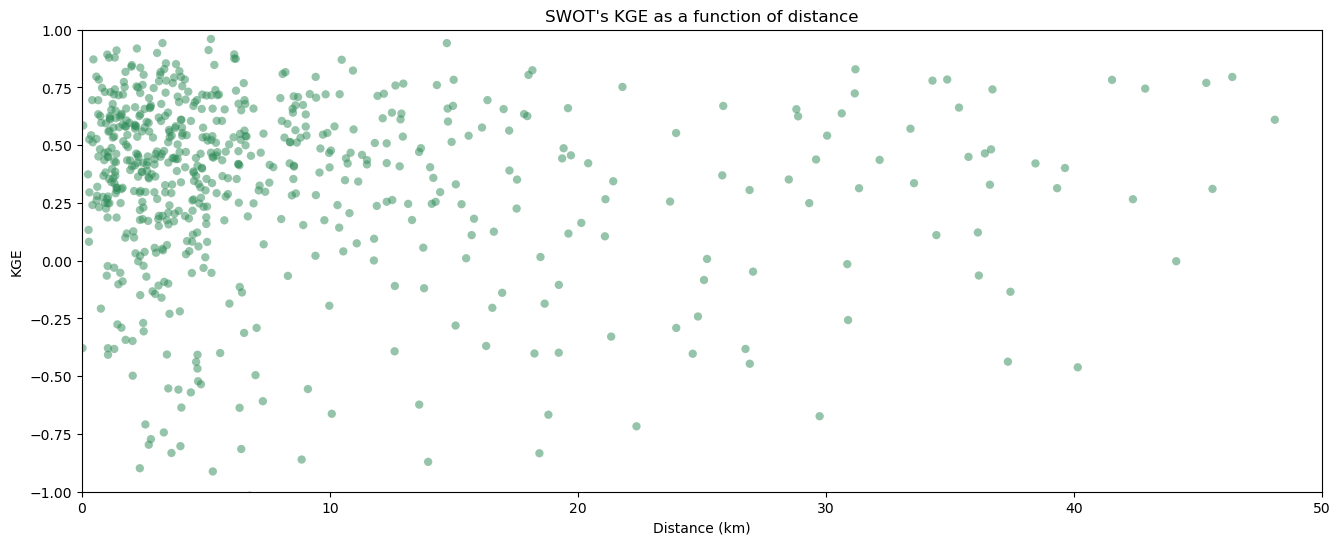

In [29]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(diag_dset['distance_d'], diag_dset['kge_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((-1,1))
plt.xlim((0,50))
plt.title("SWOT's KGE as a function of distance") 
plt.xlabel(r'Distance (km)')
plt.ylabel(r'KGE')

# Save
fig_name = f'kge_distance.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Mean swot discharge

Figure saved


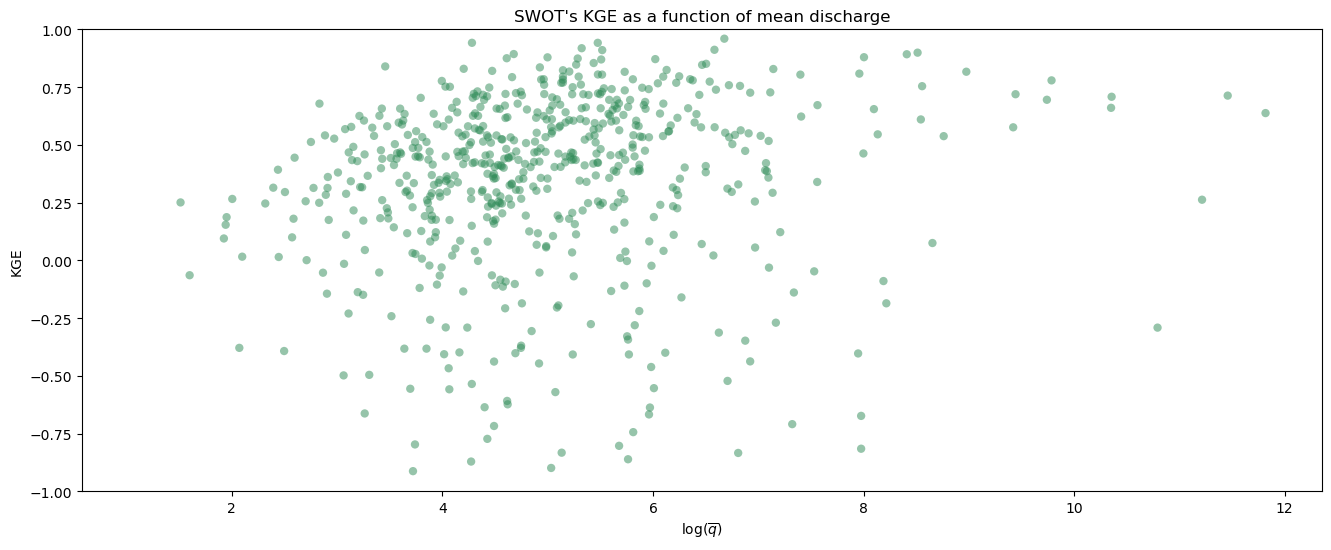

In [4]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(np.log(diag_dset['dschg_s'].mean(dim='time', skipna=True)), diag_dset['kge_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((-1,1))
#plt.xlim((0,5000))
plt.title("SWOT's KGE as a function of mean discharge") 
plt.xlabel(r'log($\overline{q}$)')
plt.ylabel(r'KGE')

# Save
fig_name = f'kge_mean_q_s.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Gloabl map

Figure saved.


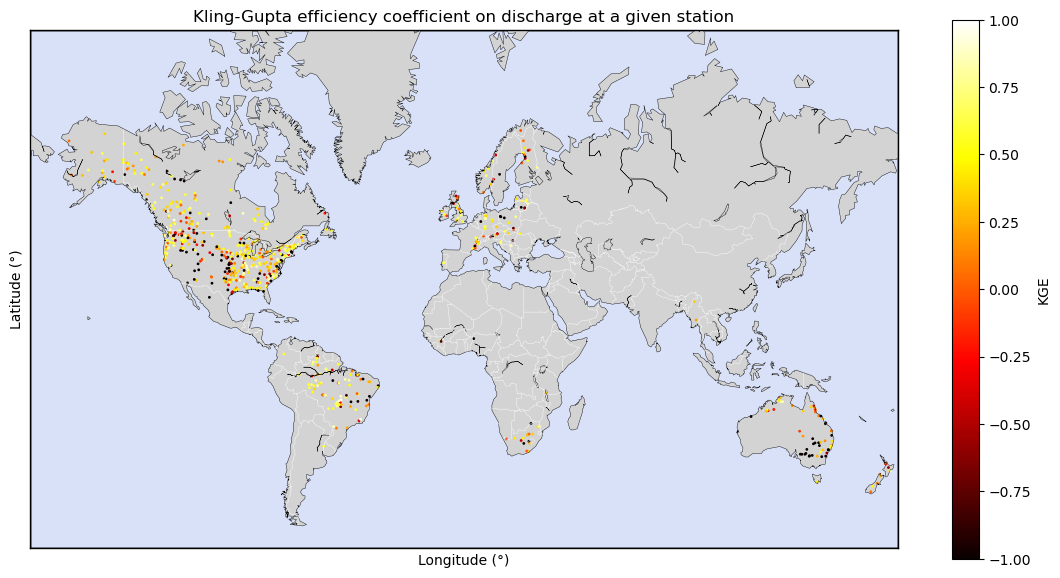

In [ ]:
# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.3)
map.drawcountries(color='w',linewidth=0.3)
map.drawmapboundary(fill_color=ocean_color) # ocean color
map.fillcontinents(color='lightgray', lake_color='lightgray')
#map.fillcontinents(color='black', lake_color='black')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(diag_dset['geox_s'].values, diag_dset['geoy_s'].values)  # [tested] if kge value is np.nan, coordinate won't be projected on map
mymap = map.scatter(x, y, c=diag_dset['kge_d'].values, cmap='hot', marker='o', alpha=1, s=1, vmin=-1,vmax=1) # [tested] automatic clip
plt.colorbar(mymap, label='KGE')
plt.title("Kling-Gupta efficiency coefficient on discharge at a given station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'kge_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved.") 
plt.show()

## **Diagnostic : Pearson**

#### Width

Figure saved


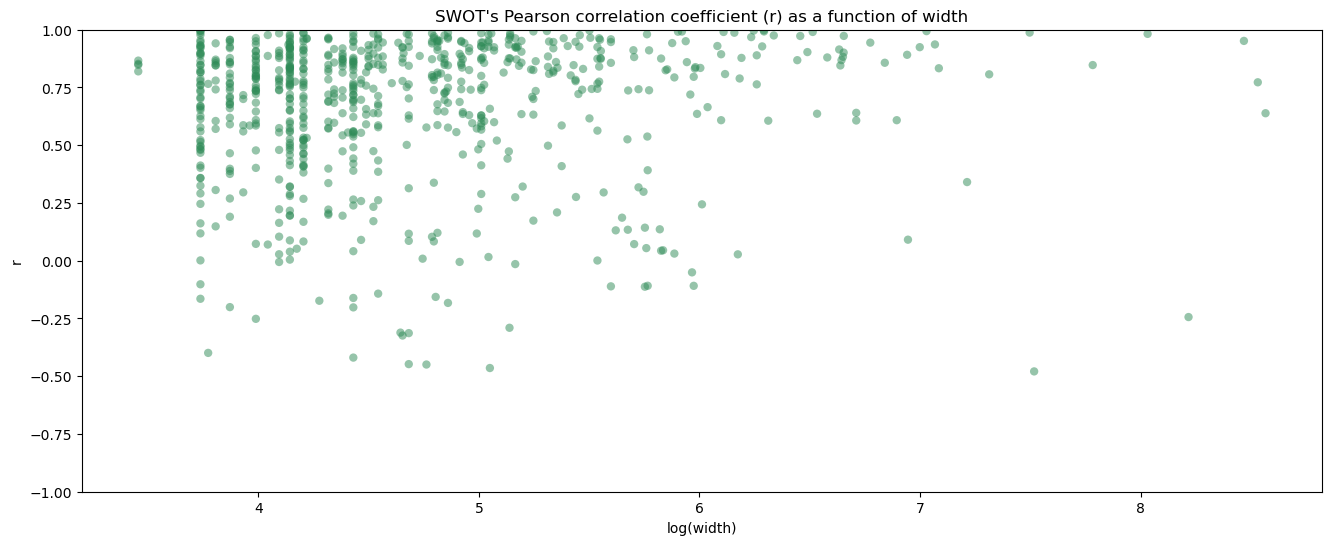

n-smallest log(width) values:  [3.45588653 3.73766962 3.77276094 3.80666249 3.87120101 3.93182563
 3.96081317 3.98898405 4.04305127 4.09434456]
CONDITION: w==3.73766962 -> []
CONDITION: w==3.87120101 -> []


In [ ]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(np.log(diag_dset['width_s']), diag_dset['pearson_corr_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((-1,1))
#plt.xlim((0,1000))
plt.title("SWOT's Pearson correlation coefficient (r) as a function of width") 
plt.xlabel(r'log(width)')
plt.ylabel(r'r')

# Save
fig_name = f'pearson_width.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

# Select points DOESNT WORK
# remove redundant elements
log_width = np.array(list(set(np.log(diag_dset['width_s'].values)))) #ndarray
# sort ascending
log_width = np.sort(log_width)
# n smallest
print("n-smallest log(width) values: ", log_width[0:10])
## w==X (one column)
condition = (
    (np.log(diag_dset['width_s'].values) == 3.73766962)
)
stations_ids_list = diag_dset.id[condition].values
print("CONDITION: w==3.73766962 ->",stations_ids_list)
## w==Y (one column)
condition = (
    (np.log(diag_dset['width_s'].values) == 3.87120101)
)
stations_ids_list = diag_dset.id[condition].values
print("CONDITION: w==3.87120101 ->",stations_ids_list)

#### Distance

Figure saved


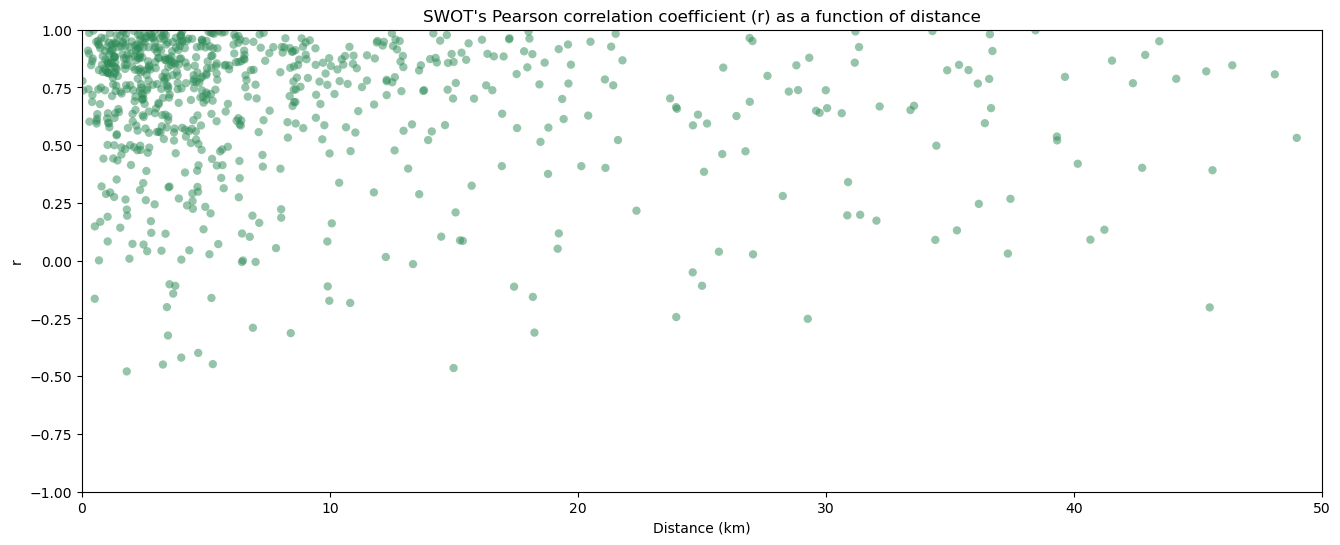

In [24]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(diag_dset['distance_d'], diag_dset['pearson_corr_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((-1,1))
plt.xlim((0,50))
plt.title("SWOT's Pearson correlation coefficient (r) as a function of distance") 
plt.xlabel(r'Distance (km)')
plt.ylabel(r'r')

# Save
fig_name = f'pearson_distance.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Mean discharge

Figure saved


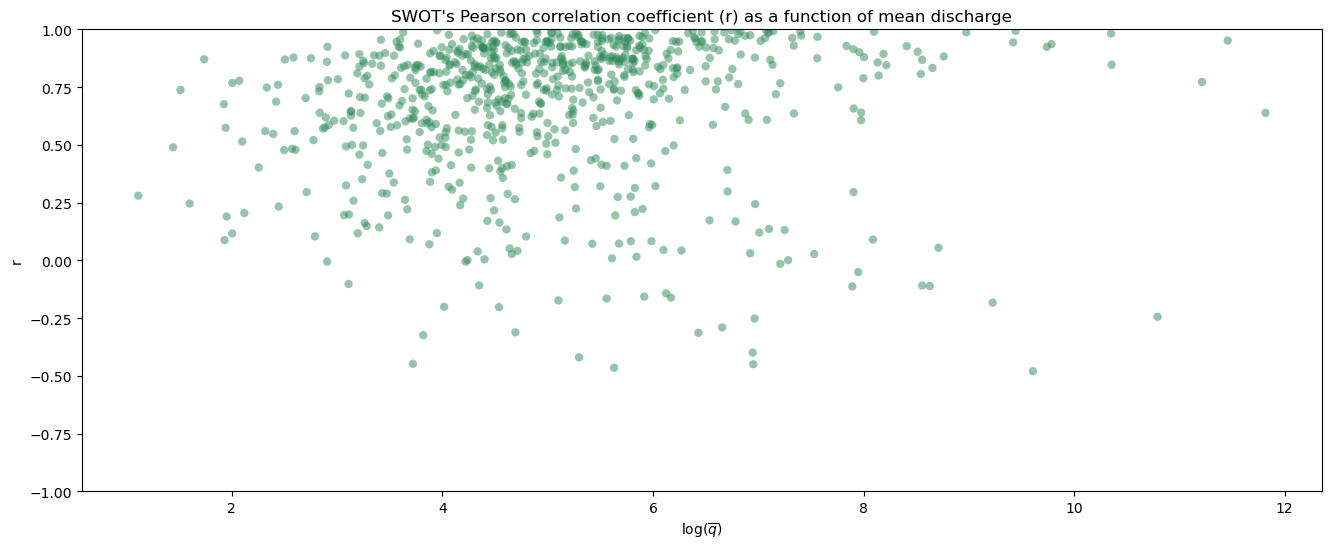

In [22]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(np.log(diag_dset['dschg_s'].mean(dim='time', skipna=True)), diag_dset['pearson_corr_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((-1,1))
#plt.xlim((0,5000))
plt.title("SWOT's Pearson correlation coefficient (r) as a function of mean discharge") 
plt.xlabel(r'log($\overline{q}$)')
plt.ylabel(r'r')

# Save
fig_name = f'pearson_mean_q_s.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Area bias

Figure saved


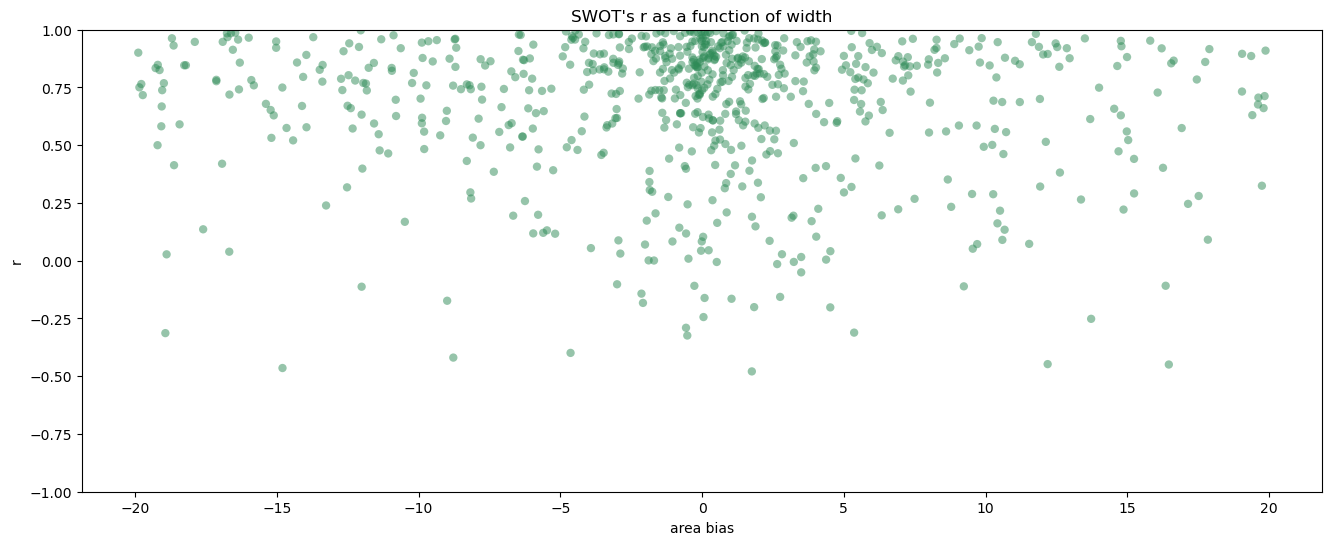

In [ ]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(diag_dset['area_bias_d'], diag_dset['pearson_corr_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((-1,1))
#plt.xlim((0,1000))
plt.title("SWOT's r as a function of width") 
plt.xlabel(r'area bias')
plt.ylabel(r'r')

# Save
fig_name = f'r_area_b.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Map

Figure saved in /obs/ecastonguay/scripts/figures


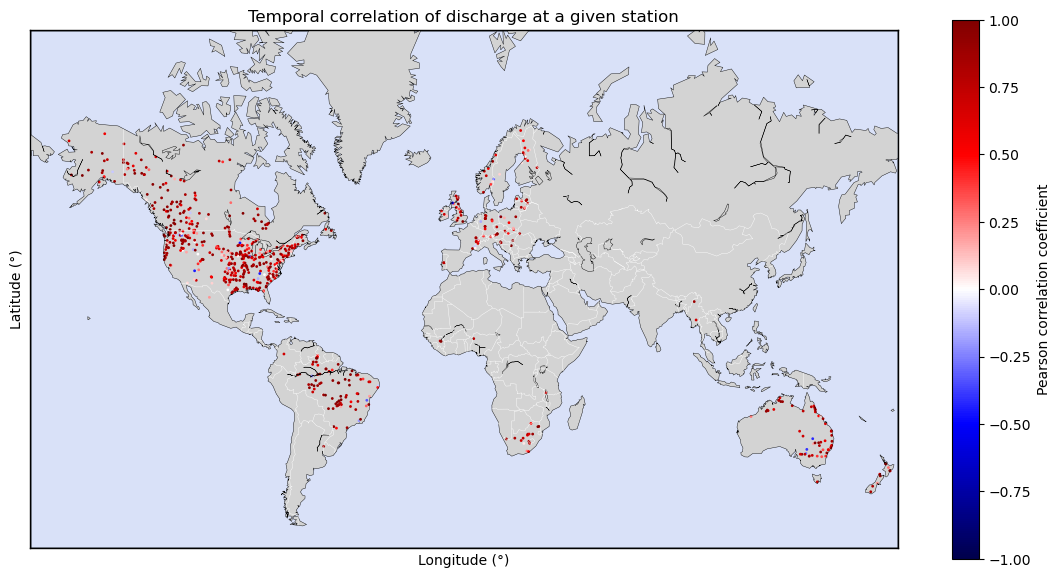

In [31]:
## If grdc discharge at a certain reach increases, does swot data do too?
## Computing Pearson corr. coeff. (linear correlation coefficient) for every station.
## https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html

# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.3)
map.drawcountries(color='w',linewidth=0.3)
map.drawmapboundary(fill_color=ocean_color) # ocean color
map.fillcontinents(color='lightgray', lake_color='lightgray')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(diag_dset['geox_s'].values, diag_dset['geoy_s'].values)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=diag_dset['pearson_corr_d'].values, cmap='seismic', marker='o', alpha=1, s=1, vmin=-1,vmax=1) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label='Pearson correlation coefficient')
plt.title("Temporal correlation of discharge at a given station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'temp_corr_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

#### Discharge bias

Figure saved


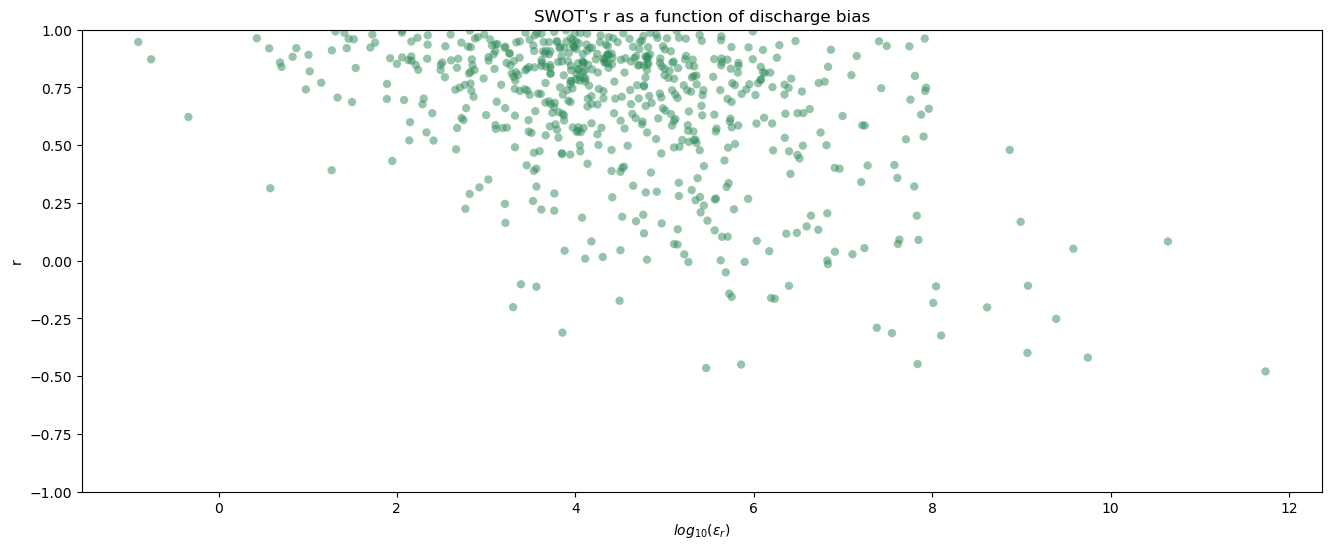

CONDITION: r>.75, bias>6 -> [4119282 4119286 4122152 4122602 4125027 4135205 4146180 4150502 4152580
 4208440 4220501 1159490 1159675 1159880 1634420 1834010 6574350 3638150
 5202135 5204255 5204400 5204450 5204451 5404270 5709112]


In [77]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(np.log(diag_dset['q_biais_d']), diag_dset['pearson_corr_d'], c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((-1,1))
#plt.xlim((0,1000))
plt.title("SWOT's r as a function of discharge bias") 
plt.xlabel(r'$log_{10}(\varepsilon_r)$')
plt.ylabel(r'r')

# Save
fig_name = f'r_q_bias.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

# Select points
## r>.75, bias>6
condition = (
    (diag_dset['pearson_corr_d'] >= 0.75) & 
    (np.log(diag_dset['q_biais_d']) >= 6)
)
stations_ids_list = diag_dset.id[condition].values
print("CONDITION: r>.75, bias>6 ->",stations_ids_list)

## **Diagnostic : biais**

#### Width

/tmp/ipykernel_8925/3185982238.py:3: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(diag_dset['width_s']), np.log(diag_dset['q_biais_d'].values), c='seagreen', alpha=0.5, edgecolors='none')


Figure saved


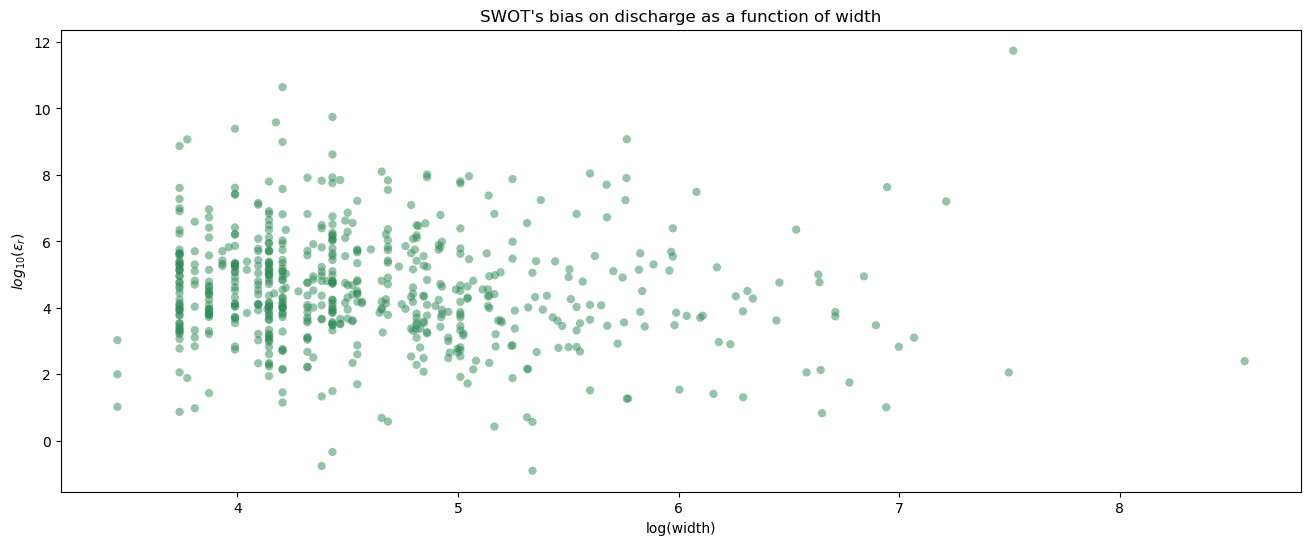

In [46]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(np.log(diag_dset['width_s']), np.log(diag_dset['q_biais_d'].values), c='seagreen', alpha=0.5, edgecolors='none')
#plt.ylim((-1,1))
#plt.xlim((0,1000))
plt.title("SWOT's bias on discharge as a function of width") 
plt.xlabel(r'log(width)')
plt.ylabel(r'$log_{10}(\varepsilon_r)$')

# Save
fig_name = f'bias_width.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Distance

/tmp/ipykernel_8925/3350332672.py:3: RuntimeWarning: invalid value encountered in log
  plt.scatter(diag_dset['distance_d'], np.log(diag_dset['q_biais_d'].values), c='seagreen', alpha=0.5, edgecolors='none')


Figure saved


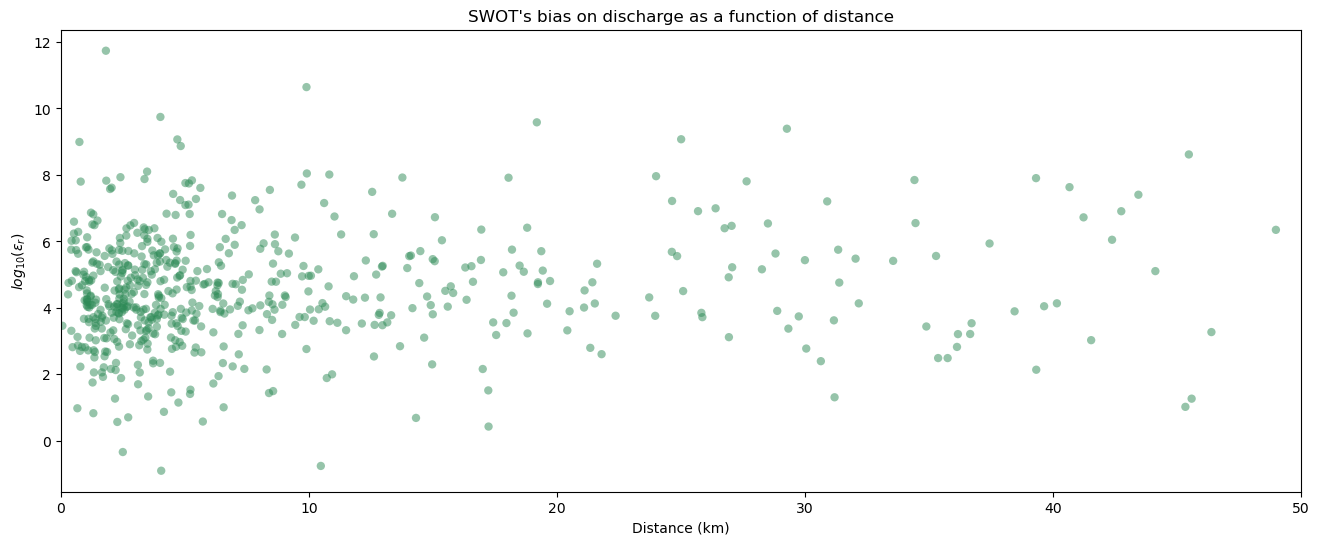

In [44]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(diag_dset['distance_d'], np.log(diag_dset['q_biais_d'].values), c='seagreen', alpha=0.5, edgecolors='none')
#plt.ylim((-1,1))
plt.xlim((0,50))
plt.title("SWOT's bias on discharge as a function of distance") 
plt.xlabel(r'Distance (km)')
plt.ylabel(r'$log_{10}(\varepsilon_r)$')

# Save
fig_name = f'bias_distance.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Mean discharge

/tmp/ipykernel_8925/2280063150.py:3: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(diag_dset['dschg_s'].mean(dim='time', skipna=True)), np.log(diag_dset['q_biais_d'].values), c='seagreen', alpha=0.5, edgecolors='none')


Figure saved


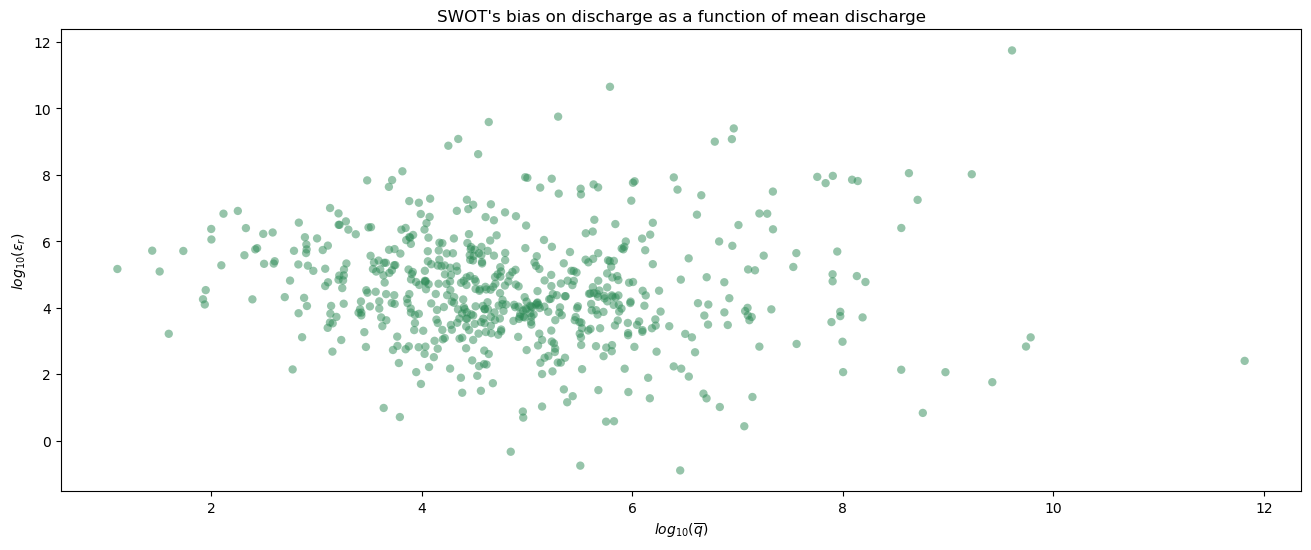

In [39]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(np.log(diag_dset['dschg_s'].mean(dim='time', skipna=True)), np.log(diag_dset['q_biais_d'].values), c='seagreen', alpha=0.5, edgecolors='none')
#plt.ylim((0,500))
#plt.xlim((0,5000))
plt.title("SWOT's bias on discharge as a function of mean discharge") 
plt.xlabel(r'$log_{10}(\overline{q}$)')
plt.ylabel(r'$log_{10}(\varepsilon_r)$')

# Save
fig_name = f'bias_mean_q_s.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Map

Figure saved


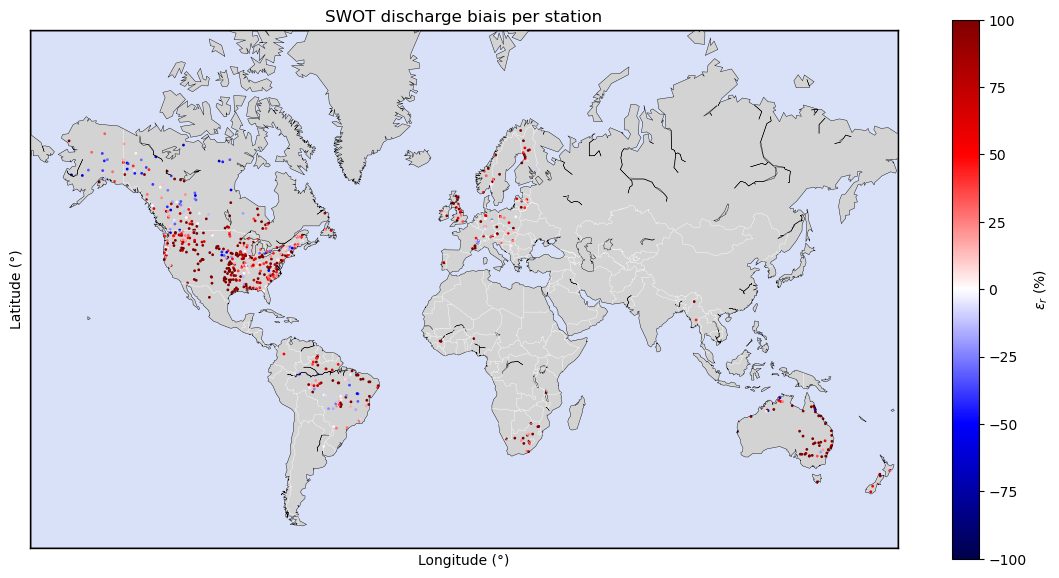

In [32]:
# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.3)
map.drawcountries(color='w',linewidth=0.3)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='lightgray', lake_color='lightgray')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(diag_dset['geox_s'].values, diag_dset['geoy_s'].values)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=diag_dset['q_biais_d'].values, cmap='seismic', marker='o', alpha=1, s=1, vmin=-100,vmax=100) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$\varepsilon_r$ (%)')
plt.title("SWOT discharge biais per station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'biais_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()


## **Diagnostic : amplitude percentage**

#### Width

Figure saved


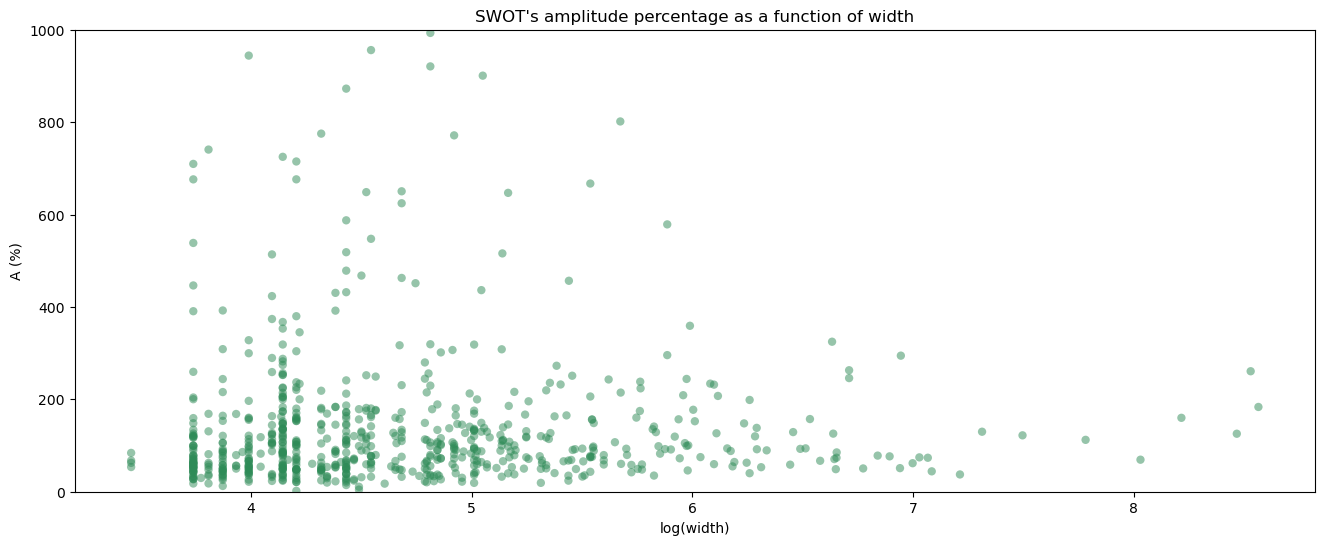

In [56]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(np.log(diag_dset['width_s']), diag_dset['ampli_percentage_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((0,1000))
#plt.xlim((0,1000))
plt.title("SWOT's amplitude percentage as a function of width") 
plt.xlabel(r'log(width)')
plt.ylabel(r'A (%)')

# Save
fig_name = f'ampli_pct_width.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Bias on areas

Figure saved


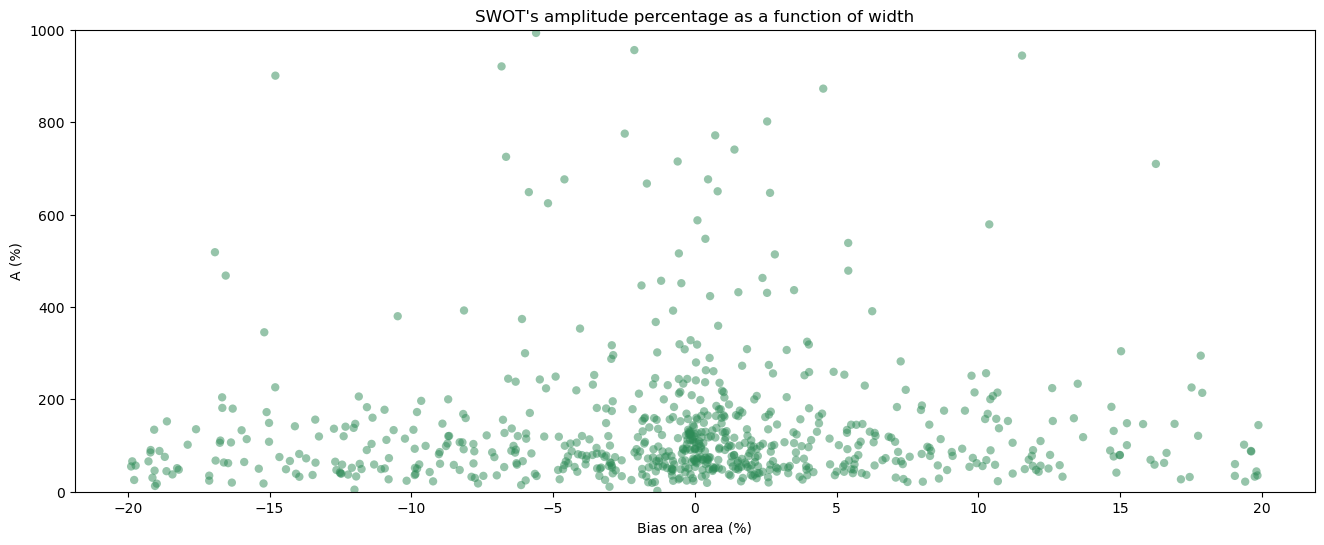

In [62]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(diag_dset['area_bias_d'].values, diag_dset['ampli_percentage_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((0,1000))
#plt.xlim((0,1000))
plt.title("SWOT's amplitude percentage as a function of width") 
plt.xlabel(r'Bias on area (%)')
plt.ylabel(r'A (%)')

# Save
fig_name = f'ampli_pct_width.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Distance

Figure saved


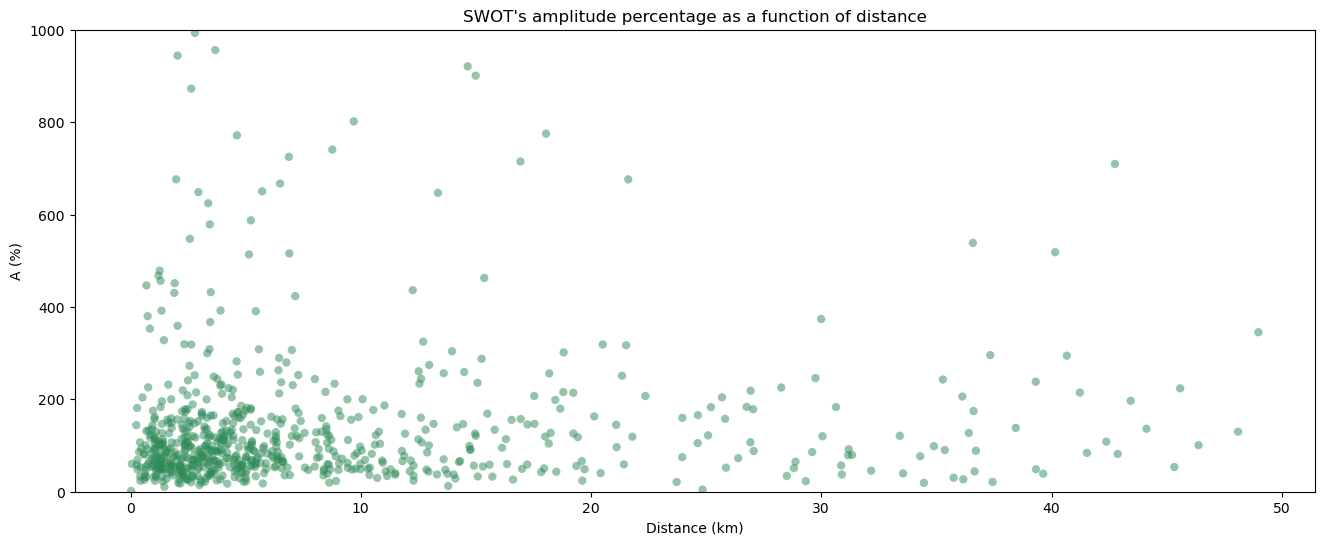

In [64]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(diag_dset['distance_d'], diag_dset['ampli_percentage_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((0,1000))
#plt.xlim((0,50))
plt.title("SWOT's amplitude percentage as a function of distance") 
plt.xlabel(r'Distance (km)')
plt.ylabel(r'A (%)')

# Save
fig_name = f'ampli_pct_distance.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Distance (with sizing based on name match)

Figure saved


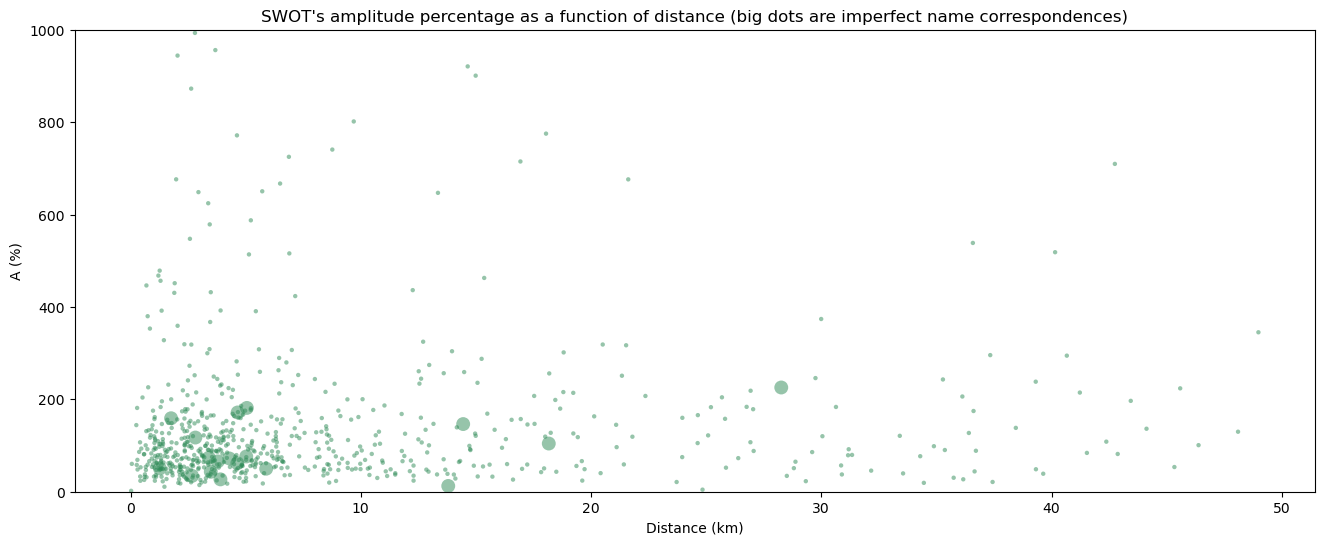

In [80]:
# Name match for size of points
from rapidfuzz import fuzz, process
names_g = np.char.lower(diag_dset['river_name_g'].values) 
names_s = diag_dset['river_name_s'].values
assert len(names_s)==len(names_g)
ratio = np.array([fuzz.ratio(names_s[i], names_g[i]) for i in range(len(names_s))])
ratio = np.where(ratio==100,10,100)

# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(diag_dset['distance_d'], diag_dset['ampli_percentage_d'].values, c='seagreen', alpha=0.5, edgecolors='none', s=ratio) # s is area, *X to make bigger
plt.ylim((0,1000))
#plt.xlim((0,50))
plt.title("SWOT's amplitude percentage as a function of distance (big dots are imperfect name correspondences)") 
plt.xlabel(r'Distance (km)')
plt.ylabel(r'A (%)')

# Save
fig_name = f'ampli_pct_distance.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Mean discharge

Figure saved


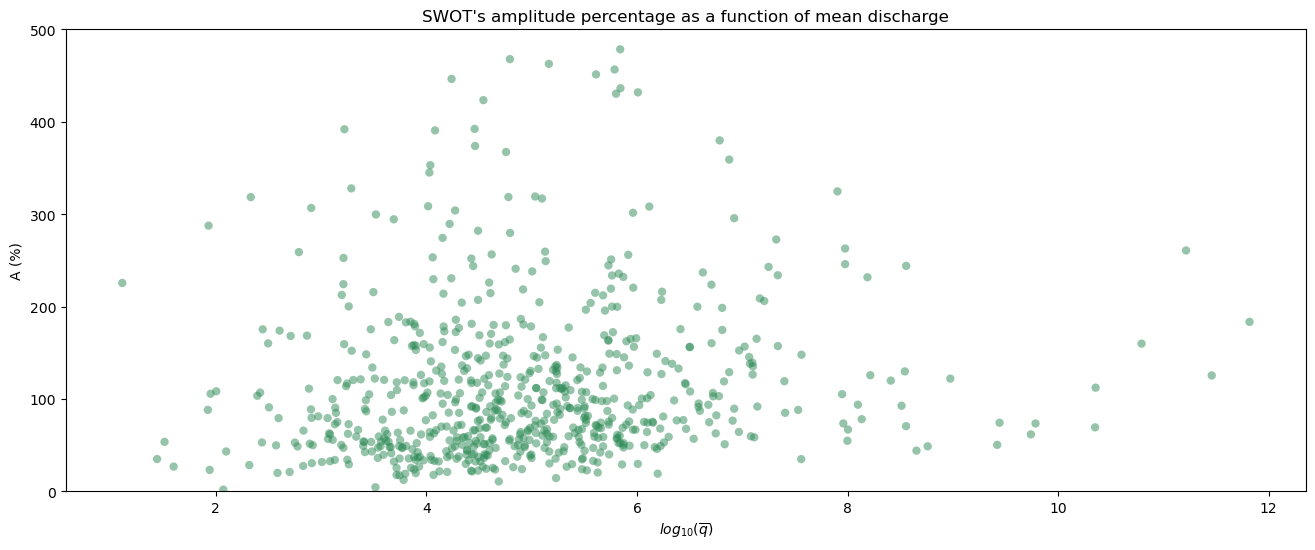

In [66]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(np.log(diag_dset['dschg_s'].mean(dim='time', skipna=True)), diag_dset['ampli_percentage_d'].values, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((0,500))
#plt.xlim((0,5000))
plt.title("SWOT's amplitude percentage as a function of mean discharge") 
plt.xlabel(r'$log_{10}(\overline{q}$)')
plt.ylabel(r'A (%)')

# Save
fig_name = f'ampli_pct_mean_q_s.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()

#### Map

Figure saved


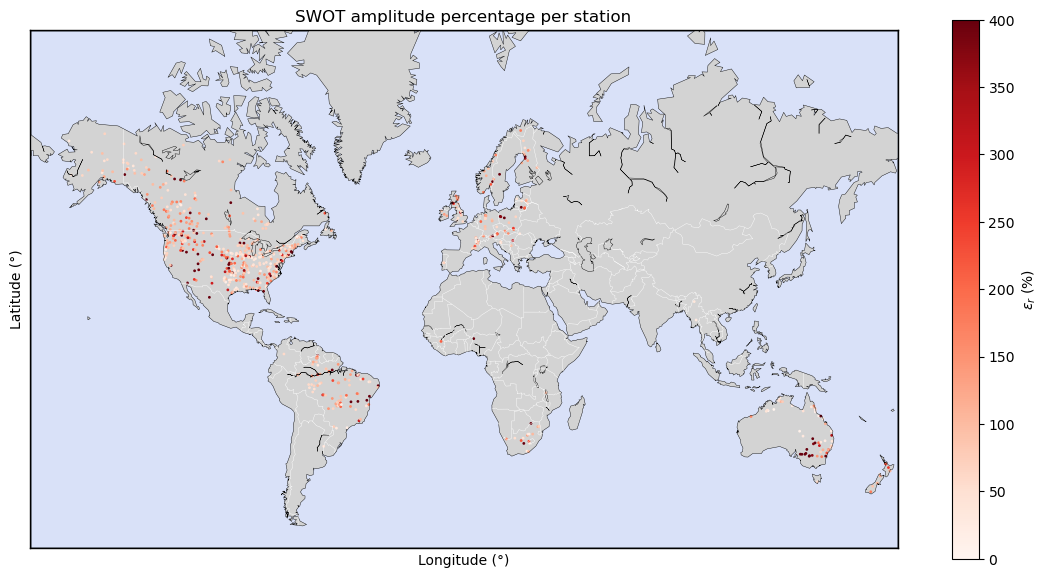

In [82]:
# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.3)
map.drawcountries(color='w',linewidth=0.3)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='lightgray', lake_color='lightgray')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(diag_dset['geox_s'].values, diag_dset['geoy_s'].values)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=diag_dset['ampli_percentage_d'].values, cmap='Reds', marker='o', alpha=1, s=1, vmin=0,vmax=400) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$\varepsilon_r$ (%)')
plt.title("SWOT amplitude percentage per station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'ampli_pct_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved") 
plt.show()


### **Other**

#### Maximum discharge per reach for swot

/tmp/ipykernel_40306/1851593545.py:5: RuntimeWarning: All-NaN slice encountered
  q_max = np.nanmax(dset_global['dschg_global_s'].values, axis=1) # value will be nan if no data


Figure saved in /obs/ecastonguay/scripts/figures/dset_global_v3


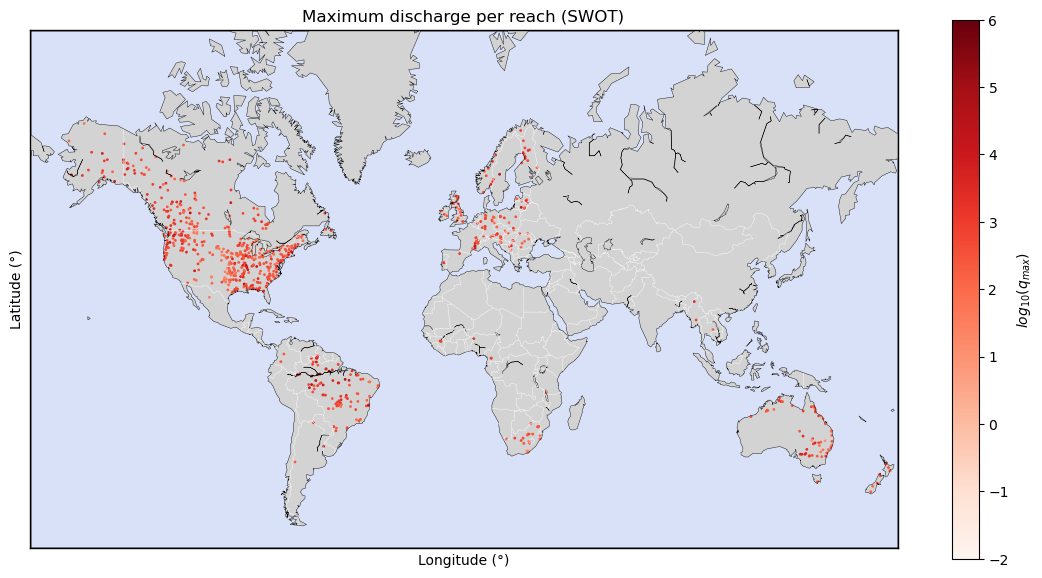

In [65]:
# Tutorial https://www.tutorialspoint.com/matplotlib/matplotlib_basemap.htm
# Colormaps https://matplotlib.org/stable/users/explain/colors/colormaps.html

# Compute maximum discharges (ignoring nans)
q_max = np.nanmax(dset_global['dschg_global_s'].values, axis=1) # value will be nan if no data

# Retrieve (lat,lon) of reaches (not stations)
x_s = dset_global['geox_global_s'].values
y_s = dset_global['geoy_global_s'].values

# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.3)
map.drawcountries(color='w',linewidth=0.3)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='lightgray', lake_color='lightgray')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_s, y_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=np.log10(q_max), cmap='Reds', marker='o', alpha=1, s=1, vmin=-2,vmax=6) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$log_{10}(q_{max})$')
plt.title("Maximum discharge per reach (SWOT)") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'max_dschg_s_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures/dset_global_v3") 
plt.show()


#### Minimum discharge per reach for swot

/tmp/ipykernel_40306/1994027348.py:5: RuntimeWarning: All-NaN slice encountered
  q_min = np.nanmin(dset_global['dschg_global_s'].values, axis=1) # value will be nan if no data


Figure saved in /obs/ecastonguay/scripts/figures/dset_global_v3


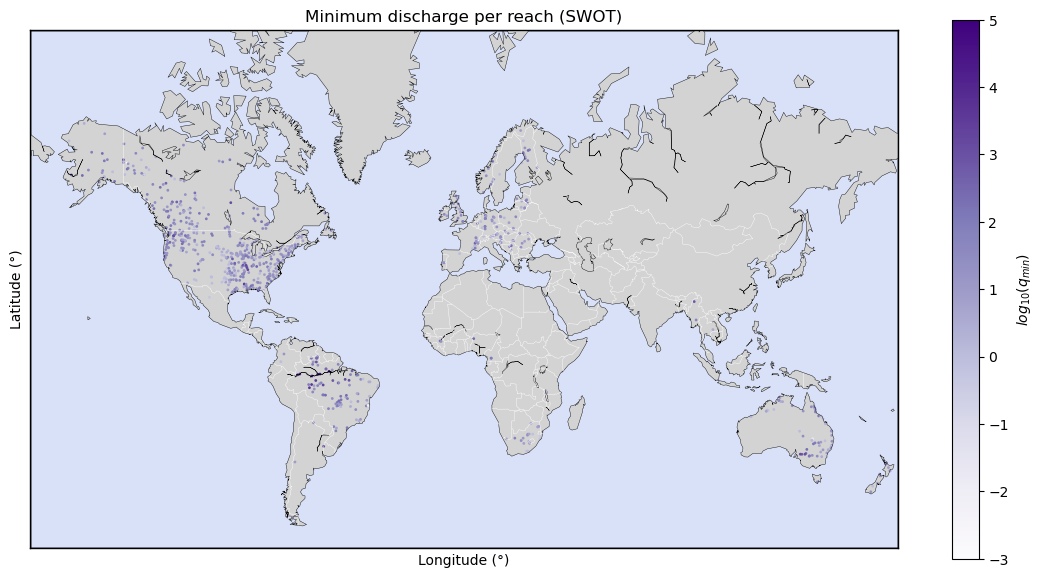

In [64]:
# Tutorial https://www.tutorialspoint.com/matplotlib/matplotlib_basemap.htm
# Colormaps https://matplotlib.org/stable/users/explain/colors/colormaps.html

# Compute maximum discharges (ignoring nans)
q_min = np.nanmin(dset_global['dschg_global_s'].values, axis=1) # value will be nan if no data

# Retrieve (lat,lon) of reaches (not stations)
x_s = dset_global['geox_global_s'].values
y_s = dset_global['geoy_global_s'].values

# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.3)
map.drawcountries(color='w',linewidth=0.3)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='lightgray', lake_color='lightgray')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_s, y_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=np.log10(q_min), cmap='Purples', marker='o', alpha=1, s=1, vmin=-3,vmax=5) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$log_{10}(q_{min})$')
plt.title("Minimum discharge per reach (SWOT)") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'min_dschg_s_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures/dset_global_v3") 
plt.show()

#### Maximum discharge per station for grdc

/tmp/ipykernel_40306/3804326895.py:5: RuntimeWarning: All-NaN slice encountered
  r_max = np.nanmax(dset_global['dschg_global_g'].values, axis=1) # value will be nan if no data


/tmp/ipykernel_40306/3804326895.py:32: RuntimeWarning: divide by zero encountered in log10
  mymap = map.scatter(x, y, c=np.log10(r_max), cmap='Reds', marker='o', alpha=1, s=1, vmin=-2,vmax=6) # s is markersize, [vmin=0,vmax=5000]


Figure saved in /obs/ecastonguay/scripts/figures


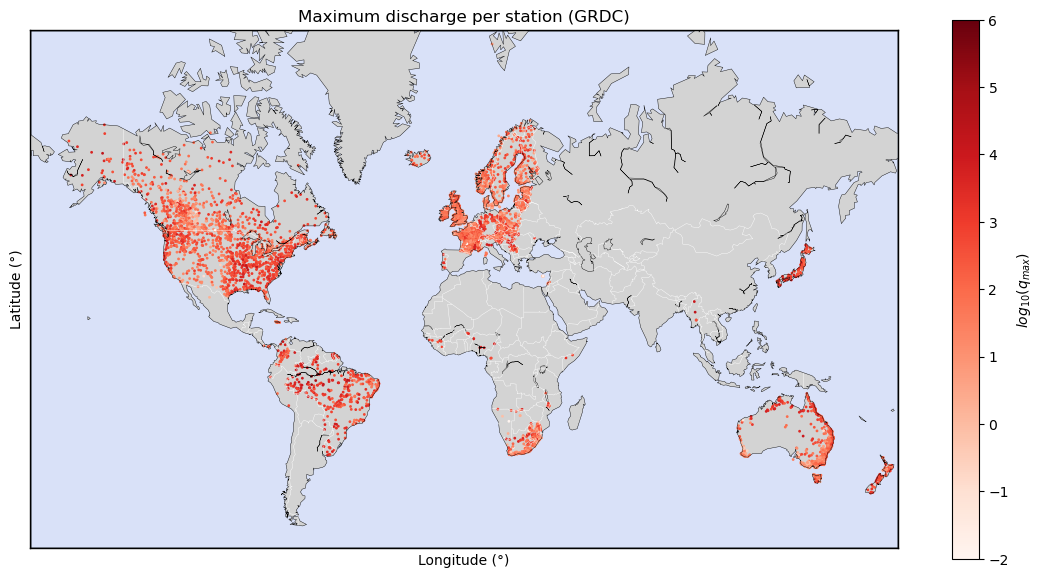

In [63]:
# Tutorial https://www.tutorialspoint.com/matplotlib/matplotlib_basemap.htm
# Colormaps https://matplotlib.org/stable/users/explain/colors/colormaps.html

# Compute maximum discharges (ignoring nans)
r_max = np.nanmax(dset_global['dschg_global_g'].values, axis=1) # value will be nan if no data

# Retrieve (lat,lon) of stations
x_s = dset_global['geox_global_g'].values
y_s = dset_global['geoy_global_g'].values

# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.3)
map.drawcountries(color='w',linewidth=0.3)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='lightgray', lake_color='lightgray')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_s, y_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=np.log10(r_max), cmap='Reds', marker='o', alpha=1, s=1, vmin=-2,vmax=6) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$log_{10}(q_{max})$')
plt.title("Maximum discharge per station (GRDC)") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'max_dschg_g_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


#### Minimum discharge per station for grdc

/tmp/ipykernel_40306/2071510703.py:5: RuntimeWarning: All-NaN slice encountered
  r_min = np.nanmin(dset_global['dschg_global_g'].values, axis=1) # value will be nan if no data
/tmp/ipykernel_40306/2071510703.py:32: RuntimeWarning: divide by zero encountered in log10
  mymap = map.scatter(x, y, c=np.log10(r_min), cmap='Purples', marker='o', alpha=1, s=1, vmin=-3,vmax=5) # s is markersize, [vmin=0,vmax=5000]


Figure saved in /obs/ecastonguay/scripts/figures


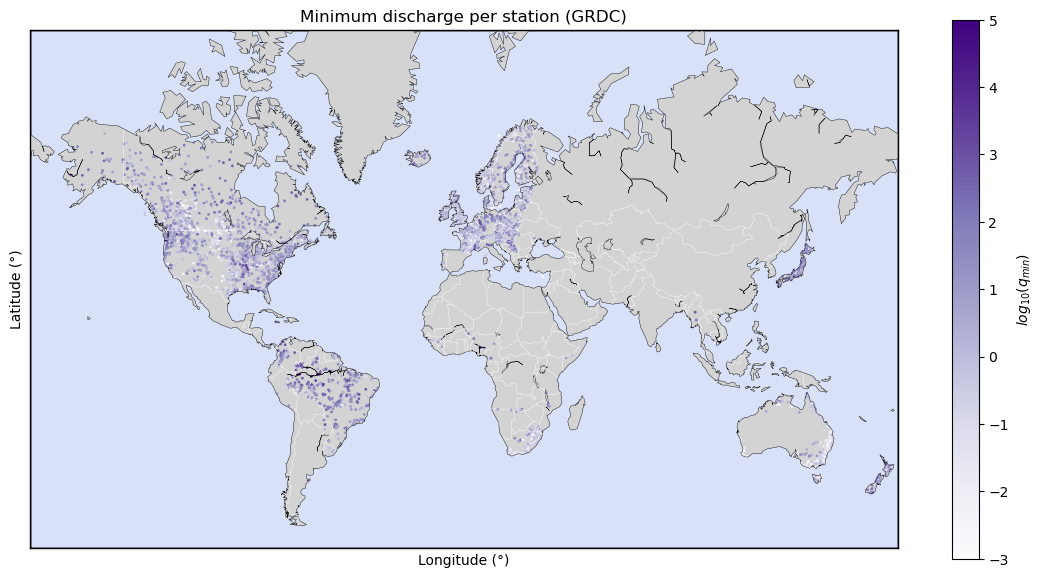

In [62]:
# Tutorial https://www.tutorialspoint.com/matplotlib/matplotlib_basemap.htm
# Colormaps https://matplotlib.org/stable/users/explain/colors/colormaps.html

# Compute maximum discharges (ignoring nans)
r_min = np.nanmin(dset_global['dschg_global_g'].values, axis=1) # value will be nan if no data

# Retrieve (lat,lon) of stations
x_s = dset_global['geox_global_g'].values
y_s = dset_global['geoy_global_g'].values

# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.3)
map.drawcountries(color='w',linewidth=0.3)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='lightgray', lake_color='lightgray')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_s, y_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=np.log10(r_min), cmap='Purples', marker='o', alpha=1, s=1, vmin=-3,vmax=5) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'$log_{10}(q_{min})$')
plt.title("Minimum discharge per station (GRDC)") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'min_dschg_g_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


#### Histogram of biais on area

In [ ]:
# Clipping the very high values (including infinites) to a defined maximum
max = 100
min = 0
clip_dist = np.clip(distance,min,max)

# Plot
plt.figure(figsize=(16, 6))
n_bins = 10
step = (max-min)/n_bins
my_bins = np.arange(min,max+1,step)
plt.hist(area_bias, color = 'seagreen', alpha=0.5)
#plt.axvline(x=10,label=f'Elimination threshold', color='tab:blue', linestyle='--', linewidth = 0.8)
plt.title(f"Histogram of the biais on the area") 
#plt.ylim((0,700))
#plt.xticks(my_bins)
plt.xlabel('Distance (km)') 
plt.ylabel('Frequency')
plt.legend()

# Save
fig_name = f'pdf_dist_10nn.png' # SELECT file name
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print("Figure saved.")
plt.show()


#### Mean absolute error (MAE)

Figure saved in /obs/ecastonguay/scripts/figures


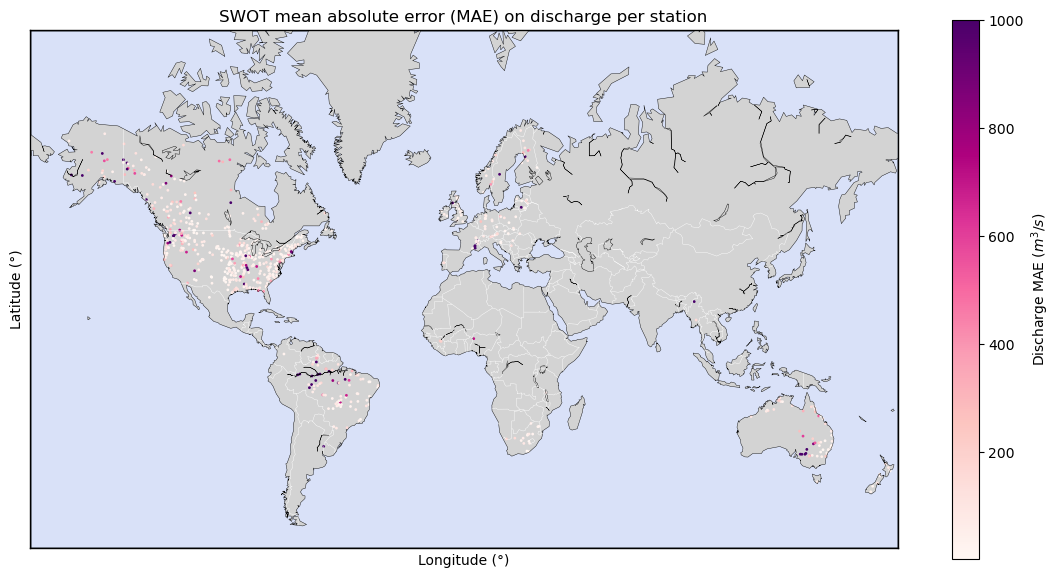

In [60]:
# Determine the 'view' of the world map
plt.figure(figsize=(14, 7))
min_lat = -60
max_lat = 80
min_lon = -180
max_lon = 180
map = Basemap(
   projection='merc', llcrnrlat=min_lat, urcrnrlat=max_lat,
   llcrnrlon=min_lon, urcrnrlon=max_lon, resolution='c')

# Draw the continental elements
ocean_color = mcolors.to_rgba('royalblue', alpha=0.1) # 'royalblue', alpha=0.1 // 'lightsteelblue', alpha=0.35
map.drawcoastlines(color='k',linewidth=0.3)
map.drawcountries(color='w',linewidth=0.3)
map.drawmapboundary(fill_color=ocean_color)
map.fillcontinents(color='lightgray', lake_color='lightgray')
#map.drawparallels(np.linspace(min_lon,max_lon,num=10))
#map.drawmeridians(np.linspace(min_lat,max_lat,num=10))

# Plot
x, y = map(x_ol_s, y_ol_s)  # Projecting latitudes and longitudes to map coordinates
mymap = map.scatter(x, y, c=mae, cmap='RdPu', marker='o', alpha=1, s=1, vmax=1000) # s is markersize, [vmin=0,vmax=5000]
plt.colorbar(mymap, label=r'Discharge MAE ($m^3/s$)')
plt.title("SWOT mean absolute error (MAE) on discharge per station") 
plt.xlabel(r'Longitude (°)')
plt.ylabel(r'Latitude (°)')

# Save
fig_name = f'mae_world.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


#### Histogram of the differences

In [1]:
## For a given station, mean of the relative error.
## Clip the last bin: https://stackoverflow.com/questions/71818401/set-the-last-bin-of-histogram-to-a-range-to-include-all-large-values-seaborn-ma
## *** add a + to the last bin so that we know 

# Compute statistic
mean_arr = bias.values

if np.isnan(mean_arr).any():
    print("Error: NaN detected.")

# Clipping the very high values (including infinites) to a defined maximum
max_err = 1000
min_err = np.nanmin(mean_arr)
clip_sum = np.clip(mean_arr,min_err,max_err)

"""# Check the number of stations containing errors bigger than 100000
ids_co = sum_err.id.where(sum_err > 15000, drop=True)
max_sum = np.nanmax(sum_err)
min_sum = np.nanmin(sum_err)
print(min_sum,max_sum)
step = np.absolute(np.max(daily_err)-np.min(daily_err))/50
my_bins = np.arange(np.min(daily_err),np.max(daily_err),step)"""

# Plot
plt.figure(figsize=(20, 8))
n_bins = 20
step = (max_err-min_err)/n_bins
my_bins = np.arange(min_err,max_err+1,step)
plt.hist(clip_sum, bins=my_bins, color = 'seagreen', alpha=0.5)
#plt.title(f"In situ runoff measurements of station {station_id} and the SWOT L4 consensus discharge \nof it's nearest corresponding reach {closest_reach_id}") 
plt.xticks(my_bins)
plt.xlabel(r'$\varepsilon_r$ (%)') 
plt.ylabel('Frequency')
plt.title("Histogram of the relative error on discharge") 

# Save
fig_name = f'pdf_rel_err.png' # SELECT file name
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures")
plt.show()


NameError: name 'bias' is not defined

#### (10 best KGE)

In [101]:
# KGE
kge2 = np.where(np.isnan(kge_matrix), -np.inf, kge_matrix)

# Ids of the n best
n_best = 10
print("-> Stations having the best KGE (worst to best):")
ind_best = np.argpartition(kge2, -n_best)[-n_best:] 
ind_best_sorted = ind_best[np.argsort(kge2[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value

# List of the 10 best
assert id_ol_g.shape == kge2.shape
kge_10_best = []
kge_10_best.append(id_ol_g[ind_best_sorted])
print(kge_10_best)

# Print
for b in range(len(ind_best_sorted)):
    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. KGE value: {kge2[ind_best_sorted][b]}")

# Median of the distribution
median_da = np.nanmedian(kge_matrix) # using kge_matrix with nan values, not kge2 
median_id_g = id_ol_g[kge_matrix==median_da]
print("-> Median value")
print(f"Station id: {median_id_g}. KGE value: {median_da}")

## Results for n best:
# [6854101, 4127502, 3666500, 2589700, 4123202, 3649619, 4245950, 6122380, 3652870, 3649424]
## Results for median: 
# 3635451

-> Stations having the best KGE (worst to best):
[array([4123300, 4127503, 4147720, 4127502, 4123202, 3649619, 4245950,
       4207020, 3652870, 3649424])]
Station id: 4123300. KGE value: 0.8797176660246212
Station id: 4127503. KGE value: 0.8925210714298935
Station id: 4147720. KGE value: 0.8933465518680402
Station id: 4127502. KGE value: 0.8994265928476851
Station id: 4123202. KGE value: 0.9104326571160282
Station id: 3649619. KGE value: 0.9118606399113878
Station id: 4245950. KGE value: 0.9186411346943373
Station id: 4207020. KGE value: 0.9419875597884041
Station id: 3652870. KGE value: 0.942076961782238
Station id: 3649424. KGE value: 0.9598945860886638
-> Median value
Station id: []. KGE value: 0.3501349799750475


#### Scatter plot function of discharge

/obs/ecastonguay/miniconda3/envs/swot-env/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in log10
  result_data = func(*input_data)


Figure saved in /obs/ecastonguay/scripts/figures


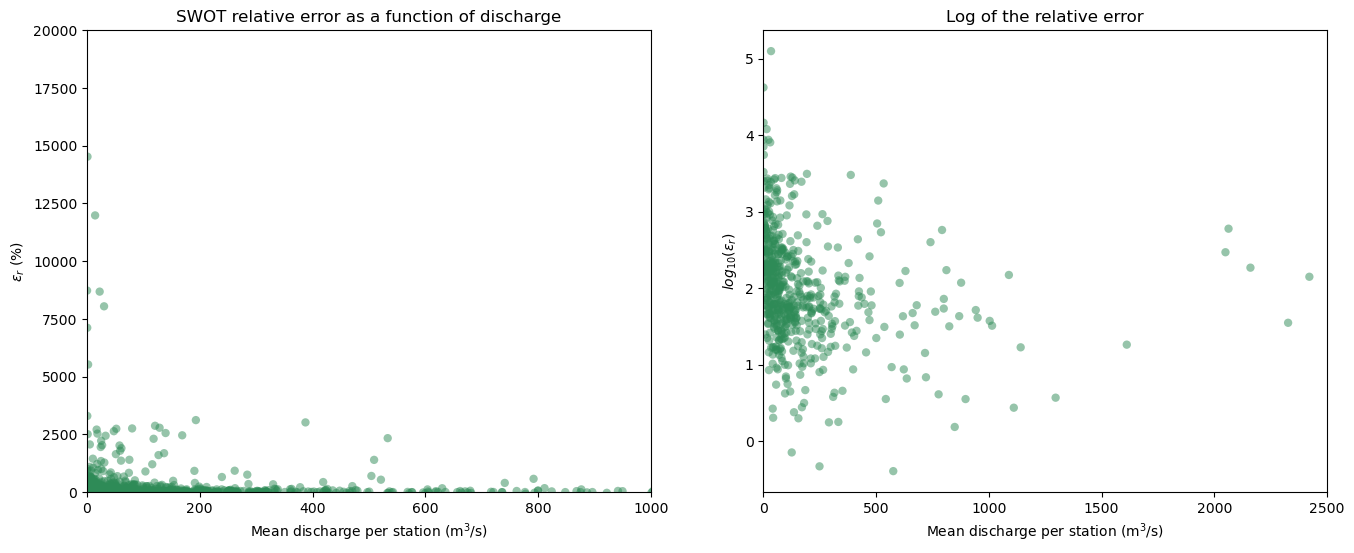

In [102]:
# Mean discharge of the river (y-axis) -> grdc data
daily_dschg = q_ol_g
mean_dschg = daily_dschg.mean(dim="time") # (2840,)

# River discharge min and max (y-axis limits)
max_dschg = np.max(mean_dschg) # 139024.55
min_dschg = np.min(mean_dschg) # 0

# Compute statistic
log_err = np.log10(bias) # (2840,)

# Scatter plot
fig, ax = plt.subplots(1,2,sharex=False, sharey=False, figsize=(16, 6))
# fig. full
ax[0].scatter(mean_dschg, bias, c='seagreen', alpha=0.5, edgecolors='none')
ax[0].set_xlim((0,1000)) # truncate 
ax[0].set_ylim((0,20000)) # truncate 
ax[0].set_title("SWOT relative error as a function of discharge") 
ax[0].set_xlabel(r'Mean discharge per station (m$^3$/s)')
ax[0].set_ylabel(r'$\varepsilon_r$ (%)')
# fig. truncated
ax[1].scatter(mean_dschg, log_err, c='seagreen', alpha=0.5, edgecolors='none')
ax[1].set_xlim((0,2500)) # truncate 
ax[1].set_title("Log of the relative error") 
ax[1].set_xlabel(r'Mean discharge per station (m$^3$/s)')
ax[1].set_ylabel(r'$log_{10}(\varepsilon_r)$')

# Save
fig_name = f'sct_dschg.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

#### Relative error vs. width

Figure saved in /obs/ecastonguay/scripts/figures


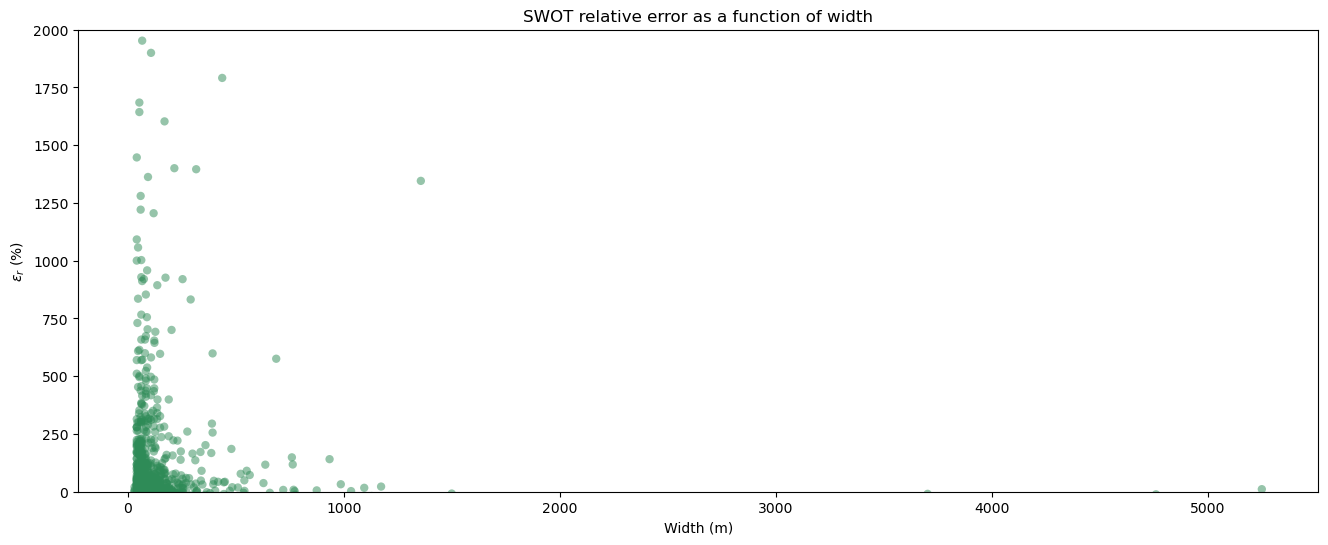

In [103]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(w_ol_swr, bias, c='seagreen', alpha=0.5, edgecolors='none')
plt.ylim((0,2000))
plt.title("SWOT relative error as a function of width") 
plt.xlabel(r'Width (m)')
plt.ylabel(r'$\varepsilon_r$ (%)')

# Save
fig_name = f'sct_w.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

#### Annual amplitude

Figure saved.


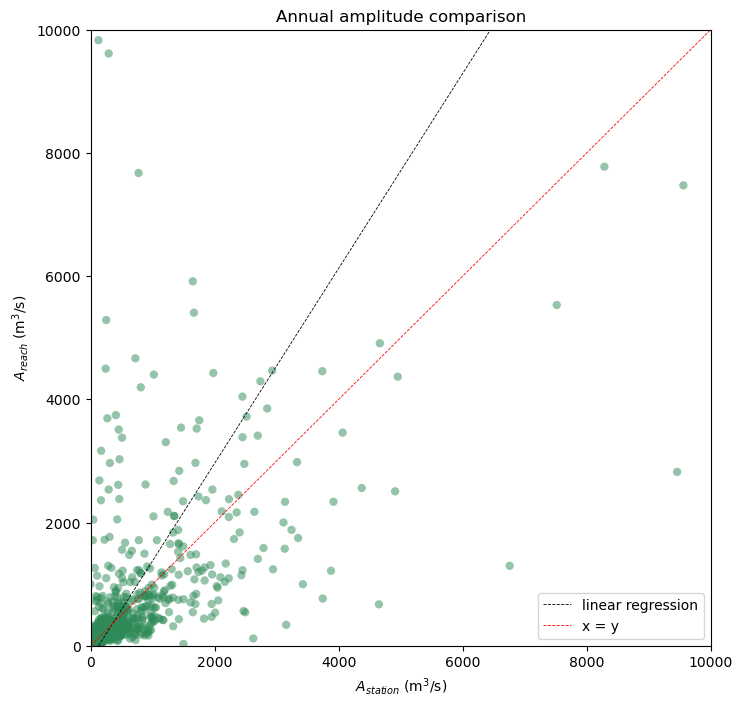

In [104]:
# Scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(ampli_g, ampli_s, c='seagreen', alpha=0.5, edgecolors='none')

# Linear regression
a, b = np.polyfit(ampli_g, ampli_s, deg=1)
plt.axline(xy1=(0, b), slope=a, label=f'linear regression', color='k', linestyle='--', linewidth = 0.6)

# X = y slope
xy = np.arange(np.nanmax(ampli_g))
s, d = np.polyfit(xy, xy, deg=1)
plt.axline(xy1=(0, d), slope=s, label=f'x = y', color='r', linestyle='--', linewidth = 0.6)

# Titles
plt.ylim((0,10000))
plt.xlim((0,10000))
plt.title("Annual amplitude comparison") 
plt.legend()
plt.xlabel(r'$A_{station}$ (m$^3$/s)')
plt.ylabel(r'$A_{reach}$ (m$^3$/s)')

# Save
fig_name = f'ampli_year_4nn_a10000.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved.") 
plt.show()

#### Mean relative discharge difference vs. distance

ValueError: x and y must be the same size

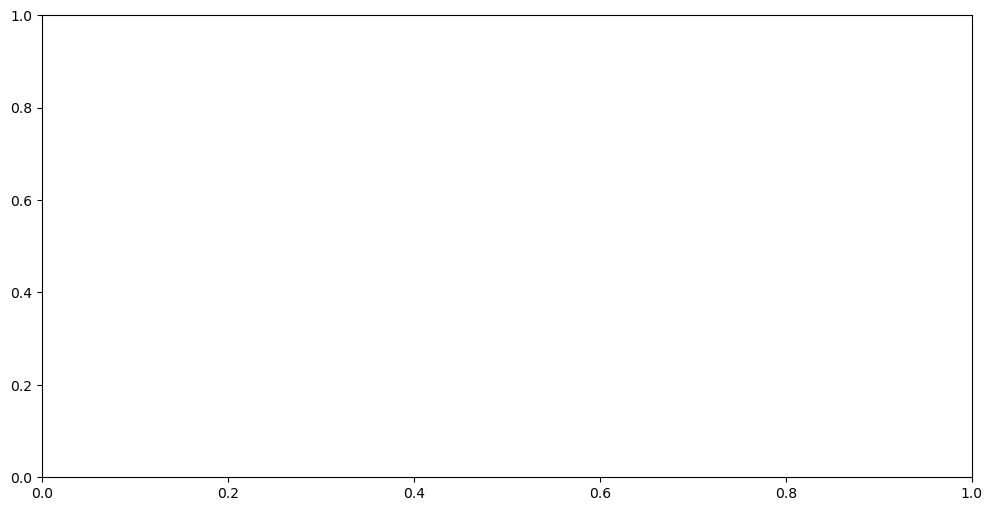

In [105]:
# Log
log_err = np.log10(bias) # (2840,)

# Scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(distance, bias, c='seagreen', alpha=0.5, edgecolors='none')

# Titles
"""plt.ylim((-10000,10000))
plt.xlim((0,100))"""
plt.title("SWOT relative error as a function of distance") 
plt.xlabel(r'Distance (km)')
plt.ylabel(r'$\varepsilon_r$ (%)')

# Save
fig_name = f'dschg_vs_dist.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

#### Pdf of the distances

-> Percentage of reaches at less than 10km distance from the station: 72.73


Figure saved.


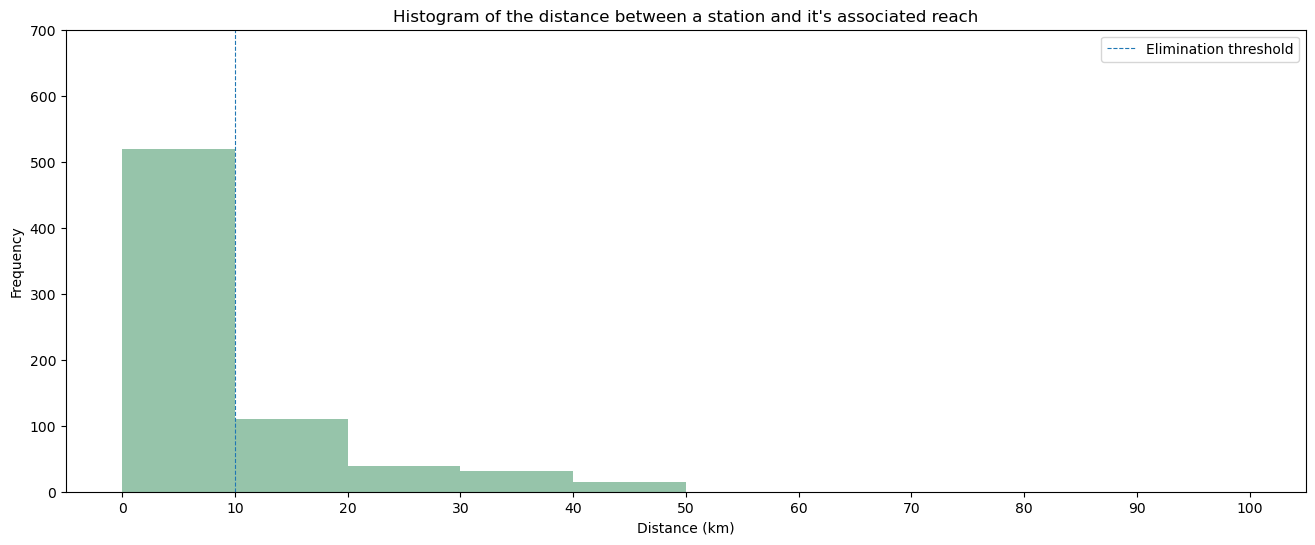

In [13]:
# Percentage of reaches at 10km or less from the station (ignore nans)
d_10km = len((distance[distance<=10]))
n_total = len(distance)
ration_10km = d_10km/n_total*100
print(f"-> Percentage of reaches at less than 10km distance from the station: {ration_10km:.2f}") # 48%

# Clipping the very high values (including infinites) to a defined maximum
max = 100
min = 0
clip_dist = np.clip(distance,min,max)

# Plot
plt.figure(figsize=(16, 6))
n_bins = 10
step = (max-min)/n_bins
my_bins = np.arange(min,max+1,step)
plt.hist(clip_dist, bins=my_bins, color = 'seagreen', alpha=0.5)
plt.axvline(x=10,label=f'Elimination threshold', color='tab:blue', linestyle='--', linewidth = 0.8)
plt.title(f"Histogram of the distance between a station and it's associated reach") 
plt.ylim((0,700))
plt.xticks(my_bins)
plt.xlabel('Distance (km)') 
plt.ylabel('Frequency')
plt.legend()

# Save
fig_name = f'pdf_dist_10nn.png' # SELECT file name
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print("Figure saved.")
plt.show()


#### Width vs discharge for swot

Figure saved in /obs/ecastonguay/scripts/figures


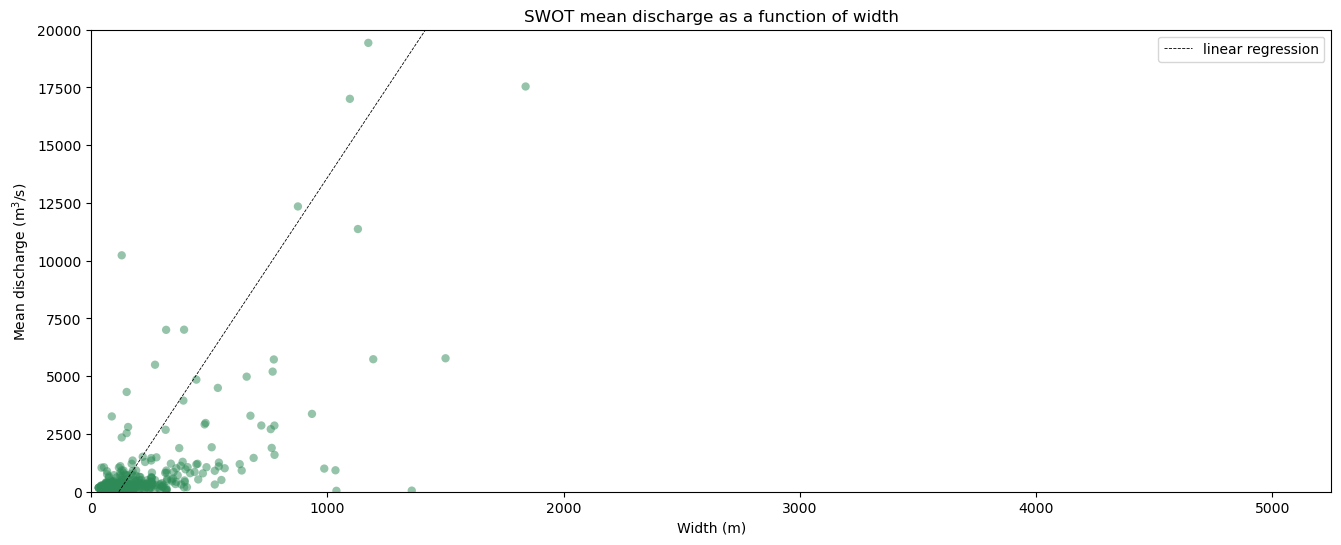

In [ ]:
# Discharge
q_s = q_ol_s.mean(dim="time")

# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(w_ol_swr, q_s, c='seagreen', alpha=0.5, edgecolors='none')

# Linear regression
ss, bb = np.polyfit(w_ol_swr, q_s, deg=1)
plt.axline(xy1=(0, bb), slope=ss, label=f'linear regression', color='k', linestyle='--', linewidth = 0.6)

# Titles
plt.ylim((0,20000))
plt.xlim((0,np.nanmax(w_ol_swr)))
plt.title("SWOT mean discharge as a function of width") 
plt.legend()
plt.xlabel(r'Width (m)')
plt.ylabel(r'Mean discharge (m$^3$/s)')

# Save
fig_name = f'dschg_vs_w.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()

### Scatter of correlation vs. width

/tmp/ipykernel_1652/1187231310.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Figure saved in /obs/ecastonguay/scripts/figures


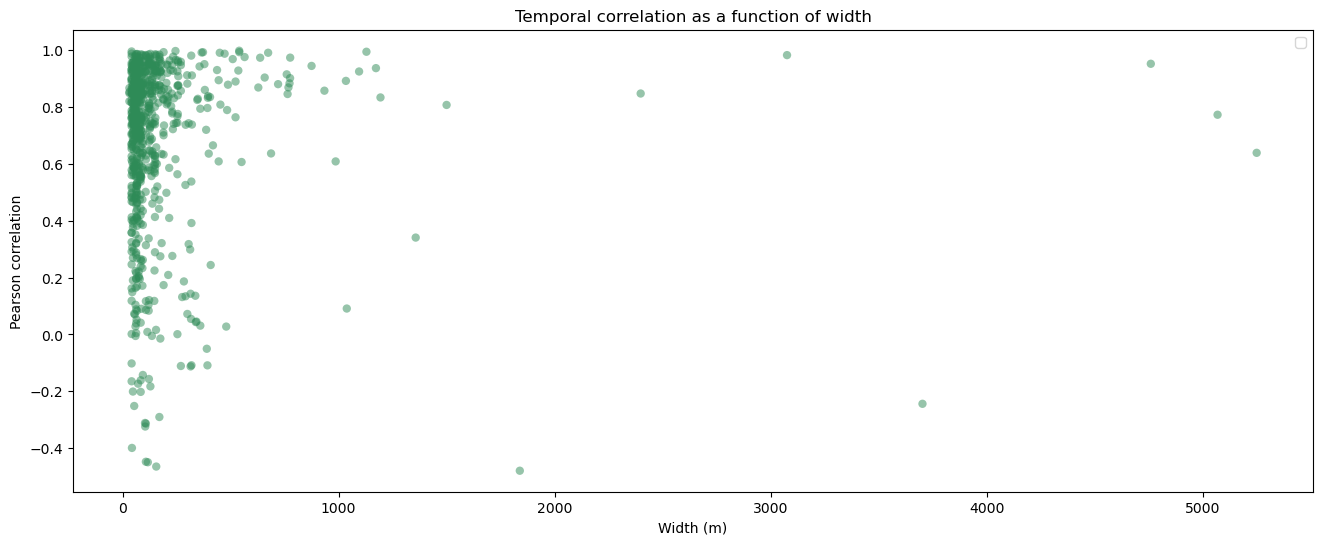

In [ ]:
# Scatter plot
plt.figure(figsize=(16, 6))
plt.scatter(w_ol_swr, r_matrix, c='seagreen', alpha=0.5, edgecolors='none')

"""# Linear regression
ss, bb = np.polyfit(w_ol_swr, r_matrix, deg=1)
plt.axline(xy1=(0, bb), slope=ss, label=f'linear regression', color='k', linestyle='--', linewidth = 0.6)"""

# Titles
"""plt.ylim((0,20000))
plt.xlim((0,np.nanmax(w_ol_swr)))"""
plt.title("Temporal correlation as a function of width") 
plt.legend()
plt.xlabel(r'Width (m)')
plt.ylabel(r'Pearson correlation')

# Save
fig_name = f'corr_vs_w.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures") 
plt.show()


#### Pdf of corr vs. width

Figure saved in /obs/ecastonguay/scripts/figures


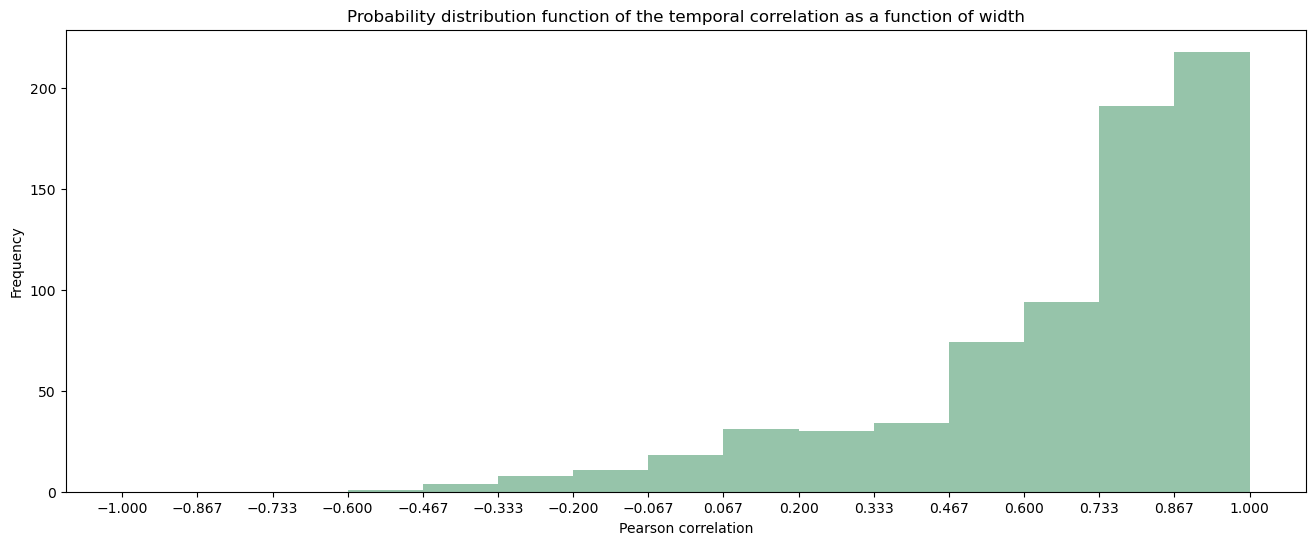

In [ ]:
# Clipping the very high values (including infinites) to a defined maximum
max = 1
min = -1
n_bins = 10
step = (max-min)/n_bins
"""clip_dist = np.clip(distance,min,max)"""

# Plot
plt.figure(figsize=(16, 6))
my_bins = np.linspace(-1, 1, 16)
plt.hist(r_matrix, bins=my_bins, color = 'seagreen', alpha=0.5)
plt.title(f"Probability distribution function of the temporal correlation as a function of width") 
#plt.ylim((0,1750))
plt.xticks(my_bins)
plt.xlabel('Pearson correlation') 
plt.ylabel('Frequency')

# Save
fig_name = f'pdf_corr.png' # SELECT file name
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved in /obs/ecastonguay/scripts/figures")
plt.show()


#### (10 best pearson coef.)

In [ ]:
# Correlations
corr2 = np.where(np.isnan(r_matrix), -np.inf, corr)
assert corr2.shape == id_ol_g.shape == corr.shape

# Ids of the n best
n_best = 10
print("-> Stations having the best pearson coeff. correlation (worst to best):")
ind_best = np.argpartition(corr2, -n_best)[-n_best:] 
ind_best_sorted = ind_best[np.argsort(corr2[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value

# List of the 10 best
pearson_10_best = []
pearson_10_best.append(id_ol_g[ind_best_sorted])
print(pearson_10_best)

# Print
for b in range(len(ind_best_sorted)):
    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. Pearson coeff. value: {corr2[ind_best_sorted][b]}")

# Median of the distribution
median_da = corr.median(skipna=True)
median_id_g = id_ol_g[corr==median_da]
print("-> Median value")
print(f"Station id: {median_id_g}. Pearson coeff. value: {median_da.values}")

## Results for n best:
# [4149122, 3634200, 3649618, 3634320, 6335060, 6645020, 3618090, 3666050, 2591800, 3627001]
## Results for median: 
# 5405070

"""for i in range(n_best):
    ind_max = np.nanargmax(corr_dlt)
    print(f"Station id: {station_id_dlt[ind_max]}. Pearson coeff. value: {corr_dlt[ind_max]}")
    # retain station ids
    id_pearson_g.append(station_id_dlt[ind_max])
    # delete
    corr_dlt = np.delete(corr_dlt,ind_max)
    station_id_dlt = np.delete(station_id_dlt,ind_max)

print(id_pearson_g)


n_nans = np.isnan(corr).sum() # using count of NaNs to offset and thus compute indices and extract values; https://stackoverflow.com/questions/56377996/using-numpy-argpartition-ignoring-nans
ind_best = np.argpartition(corr, -n_best-n_nans)[-n_best-n_nans:-n_nans] 
ind_best_sorted = ind_best[np.argsort(corr[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value
# Print
for b in range(len(ind_best_sorted)):
    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. Pearson coeff. value: {corr[ind_best_sorted][b]}")
"""

-> Stations having the best pearson coeff. correlation (worst to best):
[array([3618721, 4103550, 3649619, 4207900, 6545800, 3638200, 4127800,
       4149122, 3649618, 3618720])]
Station id: 3618721. Pearson coeff. value: 0.9902770048960053
Station id: 4103550. Pearson coeff. value: 0.9903702768367539
Station id: 3649619. Pearson coeff. value: 0.9912355243254151
Station id: 4207900. Pearson coeff. value: 0.992165427084641
Station id: 6545800. Pearson coeff. value: 0.9924355333394749
Station id: 3638200. Pearson coeff. value: 0.9925534371554184
Station id: 4127800. Pearson coeff. value: 0.9938985368455232
Station id: 4149122. Pearson coeff. value: 0.994941805671489
Station id: 3649618. Pearson coeff. value: 0.9965540810421529
Station id: 3618720. Pearson coeff. value: 0.9974919368503775
-> Median value
Station id: []. Pearson coeff. value: 0.7700270568407277


'for i in range(n_best):\n    ind_max = np.nanargmax(corr_dlt)\n    print(f"Station id: {station_id_dlt[ind_max]}. Pearson coeff. value: {corr_dlt[ind_max]}")\n    # retain station ids\n    id_pearson_g.append(station_id_dlt[ind_max])\n    # delete\n    corr_dlt = np.delete(corr_dlt,ind_max)\n    station_id_dlt = np.delete(station_id_dlt,ind_max)\n\nprint(id_pearson_g)\n\n\nn_nans = np.isnan(corr).sum() # using count of NaNs to offset and thus compute indices and extract values; https://stackoverflow.com/questions/56377996/using-numpy-argpartition-ignoring-nans\nind_best = np.argpartition(corr, -n_best-n_nans)[-n_best-n_nans:-n_nans] \nind_best_sorted = ind_best[np.argsort(corr[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value\n# Print\nfor b in range(len(ind_best_sorted)):\n    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. Pearson coeff. value: {corr[ind_best_sorted][b]}")\n'

#### (10 best NSE)

In [ ]:
# NSE
nse2_array = np.where(np.isnan(nse_array), -np.inf, nse_array)

# Ids of the n best
n_best = 10
print("-> Stations having the best NSE (worst to best):")
ind_best = np.argpartition(nse2_array, -n_best)[-n_best:] 
ind_best_sorted = ind_best[np.argsort(nse2_array[ind_best])] # argpartition does not garantee to sort so we use argsort. sort goes from smallest to biggest value

# List of the 10 best
assert id_ol_g.shape == nse2_array.shape
nse_10_best = []
nse_10_best.append(id_ol_g[ind_best_sorted])
print(nse_10_best)

# Print
for b in range(len(ind_best_sorted)):
    print(f"Station id: {id_ol_g[ind_best_sorted][b]}. NSE value: {nse2_array[ind_best_sorted][b]}")

# Median of the distribution
median_da = np.nanmedian(nse_array) # using nse_array with nan values, not nse2_array 
median_index = (np.abs(nse_array - median_da)).argmin()
median_id_g = id_ol_g[median_index]
print("-> Median value")
print(f"Station id: {median_id_g}. NSE value: {median_da}")

## Results for n best:
# [3633121, 4147720, 3635402, 3631500, 3649618, 3649409, 6335060, 3649424, 3649619, 3618090]
## Results for median: 
# 6335030

-> Stations having the best NSE (worst to best):
[array([4148541, 3652870, 3638200, 4123202, 4147720, 4207020, 6545800,
       3649618, 3649424, 3649619])]
Station id: 4148541. NSE value: 0.9357085630986166
Station id: 3652870. NSE value: 0.936778496007093
Station id: 3638200. NSE value: 0.9378288060556826
Station id: 4123202. NSE value: 0.9455076801030794
Station id: 4147720. NSE value: 0.9519344810373574
Station id: 4207020. NSE value: 0.9525958494636585
Station id: 6545800. NSE value: 0.9574249868441675
Station id: 3649618. NSE value: 0.9627231512079996
Station id: 3649424. NSE value: 0.9731039296236789
Station id: 3649619. NSE value: 0.9749201471800608
-> Median value
Station id: 4235300. NSE value: 0.25976886740172966


#### Areas scatter plot

/tmp/ipykernel_23574/4088635573.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Figure saved.


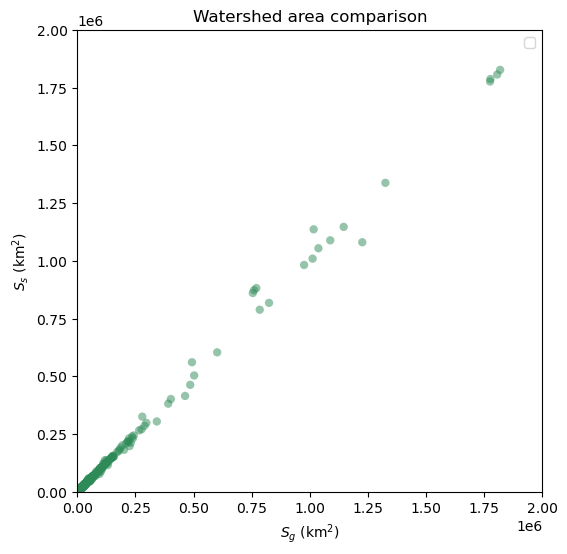

In [12]:
# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(area_ol_g, area_ol_s, c='seagreen', alpha=0.5, edgecolors='none')

"""# Linear regression
a, b = np.polyfit(ampli_g, ampli_s, deg=1)
plt.axline(xy1=(0, b), slope=a, label=f'linear regression', color='k', linestyle='--', linewidth = 0.6)

# X = y slope
xy = np.arange(np.nanmax(ampli_g))
s, d = np.polyfit(xy, xy, deg=1)
plt.axline(xy1=(0, d), slope=s, label=f'x = y', color='r', linestyle='--', linewidth = 0.6)"""

# Titles
plt.ylim((0,2000000))
plt.xlim((0,2000000))
plt.title("Watershed area comparison") 
plt.legend()
plt.xlabel(r'$S_g$ (km$^2$)')
plt.ylabel(r'$S_s$ (km$^2$)')

# Save
fig_name = f'area_scatter.png'
plt.savefig(save_path_caler+f'{fig_name}', dpi=400, bbox_inches='tight')
print(f"Figure saved.") 
plt.show()

### **Other useful plots**